# Healthcare Claim Anomaly Detection — ECOD & COPOD

**Cameroon openIMIS · 14.24M claim headers · pure NumPy, no GPU, no hyperparameters**

Third companion to `Healthcare_Claim_Autoencoder_Fraud_Detection_FIXED.ipynb` and
`Healthcare_Claim_IsolationForest_Fraud_Detection.ipynb`. Sections §1–§6 are **byte-identical**
in all three, so the score arrays are directly comparable: any difference in results comes
from the model, not the pipeline.

---

## Why these belong in the study

ECOD (Li et al., *IEEE TKDE* 2022) and COPOD (Li et al., *ICDM* 2020) are the strongest
performers relative to cost in the ADBench benchmark (Han et al., NeurIPS 2022). They are
worth running here for four reasons:

* **No hyperparameters.** Nothing to tune, nothing to overfit, nothing for a reviewer to
  accuse you of having selected on the test set. Compare with the autoencoder's seven
  interacting knobs.
* **Deterministic.** No random seed, no run-to-run variance. §11 demonstrates this rather
  than asserting it.
* **O(n·d).** One sort per feature, then a binary search per value. Scales to 14.24M rows on
  a laptop.
* **Exactly explainable by construction.** The score *is* a sum of per-dimension tail
  contributions. No SHAP, no approximation, no background-set choice — see §18. Isolation
  Forest needs TreeSHAP to get here; the autoencoder needs an approximation.

**This is the bar the other two models must clear.** If a GPU-trained autoencoder cannot beat
a parameter-free method that runs in seconds, the depth is not justified — and that is a
publishable finding in itself, not an embarrassment.

---

## Are ECOD and COPOD actually different algorithms?

Barely, and this notebook says so plainly rather than manufacturing a distinction.

Both come from the same research group and share the same skeleton: estimate each feature's
empirical CDF, convert each observation into left-tail and right-tail probabilities, correct
the tail choice per dimension using skewness, sum the negative log-probabilities across
dimensions, and take the maximum of the three aggregates. COPOD frames this through empirical
copula theory; ECOD frames it directly through per-dimension ECDFs and is presented as the
successor.

Rather than assert they differ, §9 **measures** it — Spearman rank correlation between the
two score arrays on your data. Expect a very high number. If it is above ~0.95 they are
interchangeable, and you should report one of them and mention the other, not present both as
independent evidence.

---

## The one real limitation, stated up front

Both methods treat dimensions **independently**. A claim that is unremarkable in amount and
unremarkable in service count but bizarre in their *ratio* is invisible to them.

That is the specific gap the autoencoder and Isolation Forest exist to fill. It is also why
the shared §2 engineers `NUM_CostPerService`, `NUM_CostPerDay` and `NUM_ClaimServiceGap`
explicitly — an interaction that has been turned into its own column is one ECOD *can* see.
The comparison in §20 tells you whether the models that can learn interactions actually find
anything beyond what these explicit ratios already capture.

---

## Carried over from the review

Every defect fixed in the autoencoder rebuild applies here, because the pipeline is shared:
**D1** (string categoricals one-hot encoded, not zeroed), **D2** (money parsed with unicode
separators), **D3** (post-adjudication features excluded), **D4** (Precision@K against the
test base rate), **D9** (in-flight claims excluded), **D10** (encoders fitted on train only),
**D13/D16** (no destructive clipping; missingness as indicators), **D14** (temporal split),
**D15** (baselines), **D20** (all metrics from one full-test array), **D21** (rejection codes
enumerated from data).

## §0 — Configuration

Note what is *absent*: there are no model hyperparameters. The only choices are which rows
form the reference distribution (§10) and how large a reference sample to use (§8). Both are
tested empirically rather than assumed.

In [1]:
import os, gc, json, warnings, datetime as _dt
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_recall_curve, roc_curve,
                             confusion_matrix, classification_report)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)

# ---- repository paths ------------------------------------------------------
# Resolved by walking up from the working directory to the repository root (the
# directory holding both `data/` and `models/`), so the notebook runs unchanged
# from notebooks/ or from the repository root.
_here = Path.cwd().resolve()
REPO_ROOT = next(
    (p for p in (_here, *_here.parents) if (p / "data").is_dir() and (p / "models").is_dir()),
    _here.parent,
)
DATA_DIR = REPO_ROOT / "data"
MODEL_DIR = REPO_ROOT / "models" / "model_ecod"
FIGURE_DIR = REPO_ROOT / "figures" / "ecod_copod"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "DATA_DIR":  str(DATA_DIR),
    "MODEL_DIR": str(MODEL_DIR),

    # ---- D9 ---------------------------------------------------------------
    "ACCEPTED_STATUSES": (16, 32),
    "REJECTED_STATUSES": (1,),

    # ---- D3 ---------------------------------------------------------------
    "USE_POST_ADJUDICATION_FEATURES": False,

    # ---- D2/D22 -----------------------------------------------------------
    "MONEY_HAS_DECIMALS": False,
    "MAX_MONEY_UNPARSEABLE_RATE": 0.01,
    "MAX_DATE_NAT_RATE":          0.05,

    # ---- D14 --------------------------------------------------------------
    "SPLIT_MODE": "temporal",
    "SPLIT_DATE_COL": "DateClaimed",
    "TRAIN_FRAC": 0.70,
    "VAL_FRAC":   0.15,

    # ---- ECOD / COPOD -----------------------------------------------------
    # There are NO model hyperparameters. These are the only two choices, and
    # both are decided empirically rather than guessed.
    "REFERENCE_ROWS": None,        # None => decided in §10: "accepted" | "all"
    "REF_SAMPLE_CAP": 2_000_000,   # ECDF converges fast; sensitivity tested in §8
    "REF_SAMPLE_SWEEP": (10_000, 50_000, 200_000, 1_000_000),
    "AGGREGATION": None,           # None => decided in §8: left|right|skew|max|dimmax
    "SCORE_CHUNK": 1_000_000,

    "SEED": 42,                    # used only for subsampling, never by the model

    # ---- D12 --------------------------------------------------------------
    "THRESHOLD_MODE":   "capacity",
    "AUDIT_CAPACITY_PER_DAY": 500,
    "F_BETA":           0.5,
    "COST_FN":          15000.0,
    "COST_FP":          2000.0,

    # ---- audit gates ------------------------------------------------------
    "LEAKAGE_CORR_LIMIT": 0.90,
    "MIN_FACILITY_CLAIMS": 100,

    # ---- runtime ----------------------------------------------------------
    "SAMPLE_FRAC": 1.0,
    "CHUNK_SIZE":  2_000_000,
    "EXPECTED_CLAIM_ROWS": 14_242_741,
}

DATA_DIR  = Path(CONFIG["DATA_DIR"])
MODEL_DIR = Path(CONFIG["MODEL_DIR"]); MODEL_DIR.mkdir(parents=True, exist_ok=True)
CLAIM_FILE    = DATA_DIR / "TblClaim.csv"
SERVICES_FILE = DATA_DIR / "TblClaimServices.csv"
HF_FILE       = DATA_DIR / "TblHF.csv"

SEED = CONFIG["SEED"]
np.random.seed(SEED)

print(f"pandas {pd.__version__} | numpy {np.__version__}")
import sklearn; print(f"scikit-learn {sklearn.__version__}")
print(f"\nPost-adjudication features: "
      f"{'ENABLED (post-payment model)' if CONFIG['USE_POST_ADJUDICATION_FEATURES'] else 'DISABLED (leakage-free)'}")
print(f"Split mode                : {CONFIG['SPLIT_MODE']}")
print("\nNo GPU, no seeds, no hyperparameters. The model is deterministic.")

pandas 3.0.5 | numpy 2.5.1
scikit-learn 1.9.0

Post-adjudication features: DISABLED (leakage-free)
Split mode                : temporal

No GPU, no seeds, no hyperparameters. The model is deterministic.


In [2]:
# ---------------------------------------------------------------------------
# Helper functions: parsing, transforms and audit assertions.
# Every one of these exists because of a specific silent failure in the
# original pipeline. They are loud on purpose.
# ---------------------------------------------------------------------------

_SPACE_CHARS = r"[\s\u00A0\u202F\u2009\u2007]"

def parse_money(s: pd.Series, has_decimals: bool = None) -> pd.Series:
    """D2. Parse a currency column that may be stored as text with unicode
    thousands separators (e.g. '5 020', '1 500', '12\u00a0000').

    The original pipeline used pd.to_numeric(..., errors='coerce').fillna(0.0),
    which turns every value >= 1000 into 0.0 without raising. Returns NaN for
    genuinely unparseable values -- never 0.0, because 0 is a meaningful amount.
    """
    if has_decimals is None:
        has_decimals = CONFIG["MONEY_HAS_DECIMALS"]
    if pd.api.types.is_numeric_dtype(s):
        return s.astype("float64")

    t = s.astype("string").str.strip()
    t = t.str.replace(_SPACE_CHARS, "", regex=True)      # unicode spaces
    t = t.str.replace(r"[^\d\.,\-]", "", regex=True)     # currency symbols, letters

    if has_decimals:
        # Rightmost separator followed by 1-2 digits is the decimal mark.
        t = t.str.replace(r"[\.,](?=\d{3}(?:\D|$))", "", regex=True)
        t = t.str.replace(",", ".", regex=False)
    else:
        t = t.str.replace(r"[\.,]", "", regex=True)      # XAF has no minor unit

    t = t.replace({"": pd.NA, "-": pd.NA})
    return pd.to_numeric(t, errors="coerce").astype("float64")


DATE_FORMATS = [
    "%d %b, %Y, %H:%M", "%d %b, %Y, %H:%M:%S", "%d %b, %Y",
    "%Y-%m-%d %H:%M:%S.%f", "%Y-%m-%d %H:%M:%S", "%Y-%m-%d",
    "%d/%m/%Y %H:%M", "%d/%m/%Y", "%m/%d/%Y",
]

def parse_dates(s: pd.Series, formats=DATE_FORMATS) -> pd.Series:
    """D22. Explicit format cascade instead of per-element inference.

    pd.to_datetime without format= silently returns NaT for the minority format
    when a column mixes two ('2 Apr, 2025' and '9 Apr, 2025, 20:40'), and those
    NaTs then cascaded into LOS=1.0 / delay=0.0 via the original fillna calls.
    """
    if pd.api.types.is_datetime64_any_dtype(s):
        return s
    t = s.astype("string").str.strip()
    out = pd.Series(pd.NaT, index=s.index, dtype="datetime64[ns]")
    todo = out.isna() & t.notna()
    for fmt in formats:
        if not todo.any():
            break
        parsed = pd.to_datetime(t[todo], format=fmt, errors="coerce")
        out.loc[todo] = parsed
        todo = out.isna() & t.notna()
    if todo.any():                                   # last-resort inference
        try:
            out.loc[todo] = pd.to_datetime(t[todo], errors="coerce",
                                           format="mixed", dayfirst=True)
        except (TypeError, ValueError):
            out.loc[todo] = pd.to_datetime(t[todo], errors="coerce", dayfirst=True)
    return out


def signed_log1p(x):
    """D13/D17. Compress heavy tails while preserving sign.

    The original clip(0, ...) destroyed exactly the signals the features were
    engineered to detect: negative length-of-stay (1,420 invalid date intervals
    per the DQ report), backdated submissions, and Approved > Claimed.
    """
    x = np.asarray(x, dtype="float64")
    return np.sign(x) * np.log1p(np.abs(x))


def assert_rows(df, expected, label):
    """D23. Merges against SCD Type 2 tables can silently fan out rows."""
    if expected is not None and len(df) != expected:
        raise AssertionError(
            f"[{label}] row count changed: {len(df):,} != {expected:,}. "
            "A merge key is probably non-unique (TblHF is SCD Type 2)."
        )
    print(f"  [ok] {label}: {len(df):,} rows")


def report_series(name, s, n=8):
    nn = s.notna().mean()
    print(f"  {name:<28} dtype={str(s.dtype):<16} non-null={nn:6.2%}  "
          f"sample={list(s.dropna().unique()[:n])}")

print("Helpers loaded: parse_money, parse_dates, signed_log1p, assert_rows, report_series")

Helpers loaded: parse_money, parse_dates, signed_log1p, assert_rows, report_series


## §1 — Pre-flight data integrity gate (D1, D2, D22)

**Read this output before running anything else.**

The two most damaging defects in the original pipeline were invisible: three feature columns
were constant zero and the financial columns were mass-zeroed, and neither raised an error.
This cell samples the raw CSVs, prints the real dtypes and values, and **raises** if money or
dates fail to parse above the configured tolerance.

In [3]:
PREFLIGHT_N = 200_000

print("=" * 78)
print("PRE-FLIGHT DATA INTEGRITY CHECK")
print("=" * 78)

_pf_cols = ["ClaimStatus", "Claimed", "Approved", "CareType", "VisitType",
            "DateFrom", "DateTo", "DateClaimed", "Hfid", "Icdid", "RejectionReason"]
pf = pd.read_csv(CLAIM_FILE, nrows=PREFLIGHT_N, dtype=str, usecols=lambda c: c in _pf_cols)

print(f"\n[1] RAW COLUMN TYPES AND VALUES  (first {PREFLIGHT_N:,} rows of TblClaim.csv)")
for c in _pf_cols:
    if c in pf.columns:
        report_series(c, pf[c])
    else:
        print(f"  {c:<28} *** COLUMN NOT FOUND ***")

# ---- D2: money -------------------------------------------------------------
print("\n[2] MONEY PARSING (D2)")
money_fail = {}
for col in ["Claimed", "Approved"]:
    if col not in pf.columns:
        continue
    raw   = pf[col]
    naive = pd.to_numeric(raw, errors="coerce")          # what the original did
    fixed = parse_money(raw)
    present = raw.notna()
    naive_bad = (present & naive.isna()).sum() / max(present.sum(), 1)
    fixed_bad = (present & fixed.isna()).sum() / max(present.sum(), 1)
    money_fail[col] = fixed_bad
    print(f"  {col}:")
    print(f"    original to_numeric unparseable : {naive_bad:7.2%}   "
          f"(these became 0.0 and were treated as real amounts)")
    print(f"    parse_money unparseable         : {fixed_bad:7.2%}")
    print(f"    mean  original -> fixed         : {naive.fillna(0).mean():12,.1f} -> {fixed.mean():12,.1f}")
    print(f"    max   original -> fixed         : {naive.fillna(0).max():12,.1f} -> {fixed.max():12,.1f}")
    ex = pd.DataFrame({"raw": raw, "naive": naive, "parse_money": fixed})
    ex = ex[ex["naive"].isna() & ex["parse_money"].notna()].head(5)
    if len(ex):
        print("    examples the original silently zeroed:")
        for _, r in ex.iterrows():
            print(f"        {r['raw']!r:>18}  ->  original 0.0   |   fixed {r['parse_money']:,.0f}")

# ---- D1: categoricals ------------------------------------------------------
print("\n[3] CATEGORICAL COLUMNS (D1)")
for col in ["CareType", "VisitType"]:
    if col not in pf.columns:
        continue
    numeric_ok = pd.to_numeric(pf[col], errors="coerce").notna().mean()
    print(f"  {col:<12} numeric-coercible: {numeric_ok:6.2%}  "
          f"levels: {sorted(pf[col].dropna().unique().tolist())[:10]}")
    if numeric_ok < 0.5:
        print(f"       -> the original produced a CONSTANT ZERO column here. "
              f"Now one-hot encoded.")

if HF_FILE.exists():
    hf_pf = pd.read_csv(HF_FILE, dtype=str, usecols=["HfID", "HFLevel"])
    numeric_ok = pd.to_numeric(hf_pf["HFLevel"], errors="coerce").notna().mean()
    print(f"  {'HFLevel':<12} numeric-coercible: {numeric_ok:6.2%}  "
          f"levels: {sorted(hf_pf['HFLevel'].dropna().unique().tolist())[:10]}")
    if numeric_ok < 0.5:
        print(f"       -> the original produced a CONSTANT ZERO column here. "
              f"Now one-hot encoded.")
    dup = hf_pf["HfID"].duplicated().sum()
    print(f"  TblHF HfID duplicates: {dup:,}  "
          f"{'(fan-out risk -- deduplicated in §2)' if dup else '(unique)'}")

# ---- D22: dates ------------------------------------------------------------
print("\n[4] DATE PARSING (D22)")
date_fail = {}
for col in ["DateFrom", "DateTo", "DateClaimed"]:
    if col not in pf.columns:
        continue
    present = pf[col].notna()
    naive = pd.to_datetime(pf[col], errors="coerce")
    fixed = parse_dates(pf[col])
    nb = (present & naive.isna()).sum() / max(present.sum(), 1)
    fb = (present & fixed.isna()).sum() / max(present.sum(), 1)
    date_fail[col] = fb
    print(f"  {col:<14} original NaT: {nb:7.2%}   parse_dates NaT: {fb:7.2%}")

# ---- D9: status distribution ----------------------------------------------
print("\n[5] CLAIM STATUS DISTRIBUTION (D9)")
if "ClaimStatus" in pf.columns:
    vc = pd.to_numeric(pf["ClaimStatus"], errors="coerce").value_counts(dropna=False)
    names = {1: "REJECTED", 2: "ENTERED", 4: "CHECKED", 8: "PROCESSED",
             16: "VALUATED", 32: "PAYMENT"}
    keep = set(CONFIG["ACCEPTED_STATUSES"]) | set(CONFIG["REJECTED_STATUSES"])
    for st, n in vc.items():
        tag = "keep" if st in keep else "DROP (in-flight)"
        print(f"  status {str(st):>5} {names.get(st,'?'):<10} {n:>10,}  {n/len(pf):7.2%}   {tag}")
    kept = vc[[s for s in vc.index if s in keep]].sum()
    print(f"  -> {kept/len(pf):.2%} of claims are fully adjudicated and will be used")

# ---- D21: rejection codes present at header level --------------------------
print("\n[6] REJECTION CODES AT CLAIM-HEADER LEVEL (D21)")
if "RejectionReason" in pf.columns:
    rc = pf["RejectionReason"].fillna("<null>").value_counts().head(15)
    print(f"  observed values: {rc.to_dict()}")
    print("  note: the DQ report's code taxonomy (3,4,5,7,-1,...) is measured on")
    print("        TblClaimServices line items. Codes absent here are reported in §15.")

# ---- GATE ------------------------------------------------------------------
print("\n" + "=" * 78)
problems = []
for c, r in money_fail.items():
    if r > CONFIG["MAX_MONEY_UNPARSEABLE_RATE"]:
        problems.append(f"{c}: {r:.2%} of money values unparseable "
                        f"(limit {CONFIG['MAX_MONEY_UNPARSEABLE_RATE']:.2%})")
for c, r in date_fail.items():
    if r > CONFIG["MAX_DATE_NAT_RATE"]:
        problems.append(f"{c}: {r:.2%} of dates unparseable "
                        f"(limit {CONFIG['MAX_DATE_NAT_RATE']:.2%})")

if problems:
    print("PRE-FLIGHT FAILED")
    for p in problems:
        print("  - " + p)
    raise AssertionError(
        "Fix the parser configuration before continuing. Inspect the raw values "
        "printed above and adjust MONEY_HAS_DECIMALS / DATE_FORMATS in CONFIG. "
        "Do NOT proceed by lowering the tolerance -- the original pipeline's "
        "headline results were produced by exactly this class of silent failure."
    )
print("PRE-FLIGHT PASSED -- safe to continue")
print("=" * 78)

del pf; gc.collect()

PRE-FLIGHT DATA INTEGRITY CHECK

[1] RAW COLUMN TYPES AND VALUES  (first 200,000 rows of TblClaim.csv)
  ClaimStatus                  dtype=str              non-null=100.00%  sample=['16', '4', '1', '8', '2', '32']
  Claimed                      dtype=str              non-null=100.00%  sample=['5 020', '600', '7 000', '5 000', '2 075', '5 905', '2 500', '62 770']
  Approved                     dtype=str              non-null=73.18%  sample=['5 020', '600', '7 000', '5 000', '2 000', '4 000', '2 500', '62 770']
  CareType                     dtype=str              non-null= 0.45%  sample=['OPD', 'IPD']
  VisitType                    dtype=str              non-null=100.00%  sample=['O', 'R', 'E', ' ']
  DateFrom                     dtype=str              non-null=100.00%  sample=['2 Apr, 2025', '8 Apr, 2025', '3 Apr, 2025', '4 Apr, 2025', '9 Apr, 2025', '1 Apr, 2025', '5 Apr, 2025', '6 Apr, 2025']
  DateTo                       dtype=str              non-null=100.00%  sample=['2 Apr, 202

0

## §2 — Ingestion and feature engineering (D2, D9, D13, D16, D22, D23)

Changes from the original:

* money and dates go through the validated parsers, not `to_numeric` / `to_datetime`
* only fully adjudicated claims survive (D9) — in-flight claims have NULL `Approved`,
  which the original imputed to 0 and therefore made indistinguishable from a rejection
* nothing is clipped to zero; sign is preserved and the anomalous conditions get
  explicit binary flags instead of being erased (D13)
* missing values are recorded as `_isna` indicators rather than imputed to 0 (D16)
* row counts are asserted after every merge (D23)

In [4]:
# ---------------------------------------------------------------------------
# 2.1  Service line-item aggregates
# ---------------------------------------------------------------------------
print("Aggregating TblClaimServices.csv ...")
df_services = pd.read_csv(SERVICES_FILE, usecols=["ClaimID", "PriceAsked"],
                          dtype={"PriceAsked": str}, low_memory=False)
df_services["PriceAsked"] = parse_money(df_services["PriceAsked"])   # D2

print(f"  line items                 : {len(df_services):,}")
print(f"  PriceAsked unparseable     : {df_services['PriceAsked'].isna().mean():.3%}")
print(f"  PriceAsked mean / max      : {df_services['PriceAsked'].mean():,.1f} / "
      f"{df_services['PriceAsked'].max():,.1f}")

srv_agg = (df_services.groupby("ClaimID")["PriceAsked"]
           .agg(SVC_Count="count", SVC_TotalAsked="sum",
                SVC_MaxPrice="max", SVC_MeanPrice="mean")
           .reset_index())
assert srv_agg["ClaimID"].is_unique, "srv_agg ClaimID not unique"
print(f"  claims with service lines  : {len(srv_agg):,}")

del df_services; gc.collect()

Aggregating TblClaimServices.csv ...
  line items                 : 15,774,762
  PriceAsked unparseable     : 0.000%
  PriceAsked mean / max      : 225,519.8 / 700,070,007,000.0
  claims with service lines  : 14,547,637


0

In [5]:
# ---------------------------------------------------------------------------
# 2.2  Health facility metadata  (D1: HFLevel stays categorical, D23: uniqueness)
# ---------------------------------------------------------------------------
if HF_FILE.exists():
    df_hf = pd.read_csv(HF_FILE, usecols=["HfID", "HFLevel", "HFCareType", "LegalForm"],
                        dtype=str, low_memory=False)
    df_hf["HfID"] = pd.to_numeric(df_hf["HfID"], errors="coerce")
    before = len(df_hf)
    df_hf = df_hf.dropna(subset=["HfID"]).drop_duplicates(subset=["HfID"], keep="last")
    df_hf["HfID"] = df_hf["HfID"].astype("int64")
    print(f"TblHF: {before:,} rows -> {len(df_hf):,} unique facilities "
          f"({before - len(df_hf):,} SCD Type 2 duplicates collapsed)")
    assert df_hf["HfID"].is_unique, "HfID still not unique -- merge would fan out"
    for c in ["HFLevel", "HFCareType", "LegalForm"]:
        df_hf[c] = df_hf[c].fillna("UNKNOWN").astype(str).str.strip().str.upper()
        print(f"  {c:<12} levels: {sorted(df_hf[c].unique().tolist())[:12]}")
else:
    df_hf = None
    print("TblHF.csv not found -- facility attributes will be UNKNOWN")

TblHF: 2,512 rows -> 2,512 unique facilities (0 SCD Type 2 duplicates collapsed)
  HFLevel      levels: ['C', 'D', 'H']
  HFCareType   levels: ['B', 'I', 'O']
  LegalForm    levels: ['C', 'D', 'G', 'P']


In [6]:
# ---------------------------------------------------------------------------
# 2.3  Claim headers, chunked
# ---------------------------------------------------------------------------
USECOLS = ["ClaimID", "ClaimStatus", "RejectionReason", "Claimed", "Approved",
           "DateFrom", "DateTo", "DateClaimed", "Hfid", "Icdid",
           "CareType", "VisitType"]

ACCEPTED = set(CONFIG["ACCEPTED_STATUSES"])
REJECTED = set(CONFIG["REJECTED_STATUSES"])
KEEP_STATUS = ACCEPTED | REJECTED

chunks, n_raw, n_dropped_status = [], 0, 0
rng_sample = np.random.default_rng(SEED)

print("Ingesting TblClaim.csv ...")
for i, ch in enumerate(pd.read_csv(CLAIM_FILE, usecols=USECOLS, dtype=str,
                                   chunksize=CONFIG["CHUNK_SIZE"], low_memory=False)):
    n_raw += len(ch)
    if CONFIG["SAMPLE_FRAC"] < 1.0:
        ch = ch.loc[rng_sample.random(len(ch)) < CONFIG["SAMPLE_FRAC"]].copy()

    ch["ClaimID"]     = pd.to_numeric(ch["ClaimID"], errors="coerce")
    ch["ClaimStatus"] = pd.to_numeric(ch["ClaimStatus"], errors="coerce")

    # ---- D9: keep only fully adjudicated claims ---------------------------
    before = len(ch)
    ch = ch[ch["ClaimStatus"].isin(KEEP_STATUS)].copy()
    n_dropped_status += before - len(ch)
    if ch.empty:
        continue

    ch["y"] = ch["ClaimStatus"].isin(REJECTED).astype("int8")
    ch["RejectionCode"] = (ch["RejectionReason"].fillna("0").astype(str)
                             .str.strip().str.replace(r"\.0$", "", regex=True))

    # ---- facility attributes (D1, D23) ------------------------------------
    ch["Hfid"]  = pd.to_numeric(ch["Hfid"],  errors="coerce").fillna(-1).astype("int64")
    ch["Icdid"] = pd.to_numeric(ch["Icdid"], errors="coerce").fillna(-1).astype("int64")
    if df_hf is not None:
        n_before = len(ch)
        ch = ch.merge(df_hf, left_on="Hfid", right_on="HfID", how="left")
        assert len(ch) == n_before, "TblHF merge fanned out rows"
        for c in ["HFLevel", "HFCareType", "LegalForm"]:
            ch[c] = ch[c].fillna("UNKNOWN")
    else:
        for c in ["HFLevel", "HFCareType", "LegalForm"]:
            ch[c] = "UNKNOWN"

    # ---- service aggregates (D16: absence is a signal, not a 1) -----------
    n_before = len(ch)
    ch = ch.merge(srv_agg, on="ClaimID", how="left")
    assert len(ch) == n_before, "srv_agg merge fanned out rows"
    ch["FLAG_no_service_lines"] = ch["SVC_Count"].isna().astype("int8")

    # ---- money (D2) -------------------------------------------------------
    claimed  = parse_money(ch["Claimed"])
    approved = parse_money(ch["Approved"])
    ch["NUM_Claimed"] = claimed
    ch["ISNA_Claimed"] = claimed.isna().astype("int8")
    ch["FLAG_neg_claimed"] = (claimed < 0).fillna(False).astype("int8")

    # ---- dates (D22) ------------------------------------------------------
    d_from    = parse_dates(ch["DateFrom"])
    d_to      = parse_dates(ch["DateTo"])
    d_claimed = parse_dates(ch["DateClaimed"])
    ch["DateClaimed_parsed"] = d_claimed

    los   = (d_to - d_from).dt.days
    delay = (d_claimed - d_to).dt.days
    ch["NUM_LengthOfStay"]   = los                     # D13: sign preserved
    ch["NUM_SubmissionDelay"] = delay                  # D13: sign preserved
    ch["ISNA_LengthOfStay"]   = los.isna().astype("int8")
    ch["ISNA_SubmissionDelay"] = delay.isna().astype("int8")
    ch["FLAG_negative_los"]  = (los < 0).fillna(False).astype("int8")
    ch["FLAG_backdated"]     = (delay < 0).fillna(False).astype("int8")
    ch["FLAG_los_over_year"] = (los > 365).fillna(False).astype("int8")

    # ---- derived (relative features beat absolute ones) -------------------
    ch["NUM_ServiceCount"]     = ch["SVC_Count"]
    ch["NUM_ServiceTotalAsked"] = ch["SVC_TotalAsked"]
    ch["NUM_ServiceMaxPrice"]  = ch["SVC_MaxPrice"]
    ch["NUM_ClaimServiceGap"]  = claimed - ch["SVC_TotalAsked"]
    ch["NUM_CostPerDay"]       = claimed / los.abs().clip(lower=1)
    ch["NUM_CostPerService"]   = claimed / ch["SVC_Count"].clip(lower=1)

    # ---- D3: post-adjudication outcomes, only if explicitly enabled -------
    if CONFIG["USE_POST_ADJUDICATION_FEATURES"]:
        ch["NUM_Approved"]        = approved
        ch["NUM_ClaimedMinusApproved"] = claimed - approved     # sign preserved
        ch["NUM_ApprovalRatio"]   = np.where(claimed.notna() & (claimed != 0),
                                             approved / claimed, np.nan)
        ch["FLAG_approved_over_claimed"] = (approved > claimed).fillna(False).astype("int8")

    keep = (["ClaimID", "y", "RejectionCode", "Hfid", "Icdid", "DateClaimed_parsed",
             "CareType", "VisitType", "HFLevel", "HFCareType", "LegalForm"]
            + [c for c in ch.columns if c.startswith(("NUM_", "FLAG_", "ISNA_"))])
    chunks.append(ch[keep].copy())
    print(f"  chunk {i+1}: kept {len(ch):,}")
    del ch; gc.collect()

df = pd.concat(chunks, ignore_index=True)
del chunks, srv_agg; gc.collect()

if CONFIG["SAMPLE_FRAC"] >= 1.0 and CONFIG["EXPECTED_CLAIM_ROWS"]:
    assert n_raw == CONFIG["EXPECTED_CLAIM_ROWS"], \
        f"read {n_raw:,} rows, expected {CONFIG['EXPECTED_CLAIM_ROWS']:,}"

print(f"\nRaw claim headers read       : {n_raw:,}")
print(f"Dropped as in-flight (D9)    : {n_dropped_status:,}")
print(f"Adjudicated claims retained  : {len(df):,}")
print(f"Rejection rate (population)  : {df['y'].mean():.4%}")
print(f"Date range                   : {df['DateClaimed_parsed'].min()} .. "
      f"{df['DateClaimed_parsed'].max()}")

Ingesting TblClaim.csv ...
  chunk 1: kept 415,083
  chunk 2: kept 356,849
  chunk 3: kept 430,288
  chunk 4: kept 345,238
  chunk 5: kept 438,072
  chunk 6: kept 378,463
  chunk 7: kept 351,733
  chunk 8: kept 69,698

Raw claim headers read       : 14,242,741
Dropped as in-flight (D9)    : 11,457,317
Adjudicated claims retained  : 2,785,424
Rejection rate (population)  : 15.8156%
Date range                   : 1995-02-14 00:00:00 .. 2029-05-25 00:00:00


## §3 — Feature inventory and leakage control (D3)

The feature set is declared explicitly here rather than assembled implicitly, so that what
the model sees is auditable in one place.

`USE_POST_ADJUDICATION_FEATURES = False` removes `Approved`, `Claimed − Approved` and the
approval ratio. Those are **outputs of the process being predicted**: the DQ report states
that status 1 means "rejected entirely (0 XAF approved)", so with them present the label is
a deterministic function of the input and any resulting AUC is an artefact.

In [7]:
NUM_COLS  = sorted([c for c in df.columns if c.startswith("NUM_")])
FLAG_COLS = sorted([c for c in df.columns if c.startswith("FLAG_")])
ISNA_COLS = sorted([c for c in df.columns if c.startswith("ISNA_")])
CAT_COLS  = ["CareType", "VisitType", "HFLevel", "HFCareType", "LegalForm"]
HIGHCARD_COLS = ["Hfid", "Icdid"]

# Money-scaled quantities get signed_log1p; bounded/ratio quantities do not.
LOG_COLS = [c for c in NUM_COLS if any(k in c for k in
            ["Claimed", "Approved", "TotalAsked", "MaxPrice", "Gap",
             "CostPer", "ServiceCount"])]
LINEAR_COLS = [c for c in NUM_COLS if c not in LOG_COLS]

print(f"Numeric      ({len(NUM_COLS):>2}): {NUM_COLS}")
print(f"  log1p      ({len(LOG_COLS):>2}): {LOG_COLS}")
print(f"  linear     ({len(LINEAR_COLS):>2}): {LINEAR_COLS}")
print(f"Flags        ({len(FLAG_COLS):>2}): {FLAG_COLS}")
print(f"Missingness  ({len(ISNA_COLS):>2}): {ISNA_COLS}")
print(f"Categorical  ({len(CAT_COLS):>2}): {CAT_COLS}")
print(f"High-card    ({len(HIGHCARD_COLS):>2}): {HIGHCARD_COLS}")

print(f"\nFlag prevalence (these were all clipped to zero in the original):")
for c in FLAG_COLS + ISNA_COLS:
    print(f"  {c:<32} {df[c].mean():7.4%}   ({int(df[c].sum()):,} claims)")

if CONFIG["USE_POST_ADJUDICATION_FEATURES"]:
    print("\n*** WARNING: post-adjudication features are ENABLED. ***")
    print("    Rejection implies 0 XAF approved, so the label is recoverable from the")
    print("    features. Results are valid only for a post-payment audit model and must")
    print("    be reported as such.")

Numeric      ( 9): ['NUM_ClaimServiceGap', 'NUM_Claimed', 'NUM_CostPerDay', 'NUM_CostPerService', 'NUM_LengthOfStay', 'NUM_ServiceCount', 'NUM_ServiceMaxPrice', 'NUM_ServiceTotalAsked', 'NUM_SubmissionDelay']
  log1p      ( 7): ['NUM_ClaimServiceGap', 'NUM_Claimed', 'NUM_CostPerDay', 'NUM_CostPerService', 'NUM_ServiceCount', 'NUM_ServiceMaxPrice', 'NUM_ServiceTotalAsked']
  linear     ( 2): ['NUM_LengthOfStay', 'NUM_SubmissionDelay']
Flags        ( 5): ['FLAG_backdated', 'FLAG_los_over_year', 'FLAG_neg_claimed', 'FLAG_negative_los', 'FLAG_no_service_lines']
Missingness  ( 3): ['ISNA_Claimed', 'ISNA_LengthOfStay', 'ISNA_SubmissionDelay']
Categorical  ( 5): ['CareType', 'VisitType', 'HFLevel', 'HFCareType', 'LegalForm']
High-card    ( 2): ['Hfid', 'Icdid']

Flag prevalence (these were all clipped to zero in the original):
  FLAG_backdated                   0.0004%   (12 claims)
  FLAG_los_over_year               0.0539%   (1,501 claims)
  FLAG_neg_claimed                 0.0016%   (45 cl

## §4 — Data audit gate (D1, D3, D25)

The original had a `valid_mask` line that could never be `False`, so the missing-data audit
it implied never ran. This is the real version, and it fails the run rather than warning:

* **zero-variance check** — catches D1 (`CareType`, `VisitType`, `HFLevel` were constant zero)
* **leakage tripwire** — any feature correlating with the label above `LEAKAGE_CORR_LIMIT`
  stops the run
* **redundancy check** — near-duplicate feature pairs, which an autoencoder double-counts
  in the reconstruction error

In [8]:
audit_n = min(len(df), 500_000)
aud = df.sample(audit_n, random_state=SEED)

print("=" * 78)
print("DATA AUDIT")
print("=" * 78)

print("\n[1] NUMERIC SUMMARY")
desc = aud[NUM_COLS].describe().T[["count", "mean", "std", "min", "50%", "max"]]
desc["na_rate"] = 1 - aud[NUM_COLS].notna().mean()
print(desc.to_string(float_format=lambda v: f"{v:,.3f}"))

print("\n[2] ZERO-VARIANCE CHECK (D1)")
def _is_const(col):
    v = aud[col].astype("float64").values
    return (np.isfinite(v).sum() == 0) or (float(np.nanstd(v)) == 0.0)

# A constant NUMERIC or CATEGORICAL feature is the D1 failure: a real signal that
# was destroyed by bad type handling. This must stop the run.
fatal = [c for c in NUM_COLS if _is_const(c)]
fatal += [c for c in CAT_COLS if aud[c].nunique(dropna=False) <= 1]
if fatal:
    raise AssertionError(
        f"Constant numeric/categorical features: {fatal}\n"
        "This is the failure mode that made FE_CareType / FE_VisitType / FE_HFLevel "
        "invisible in the original run -- a real column silently collapsed to one value. "
        "Fix the source parsing before continuing; do not drop the column."
    )

# A constant FLAG_/ISNA_ column is different: the condition simply never occurs in
# this extract. Harmless, but it must be dropped rather than fed to the model as a
# dead input (and a scaler would divide by a zero standard deviation).
dead = [c for c in FLAG_COLS + ISNA_COLS if _is_const(c)]
if dead:
    print(f"  dropping {len(dead)} indicator(s) with no occurrences: {dead}")
    FLAG_COLS = [c for c in FLAG_COLS if c not in dead]
    ISNA_COLS = [c for c in ISNA_COLS if c not in dead]
print(f"  [ok] no constant numeric/categorical features "
      f"({len(NUM_COLS)} numeric, {len(FLAG_COLS)+len(ISNA_COLS)} indicators retained)")

print("\n[3] LEAKAGE TRIPWIRE (D3)")
corrs = {}
yv = aud["y"].astype("float64").values
for c in NUM_COLS + FLAG_COLS + ISNA_COLS:
    v = aud[c].astype("float64").values
    m = np.isfinite(v)
    if m.sum() > 1000 and np.nanstd(v[m]) > 0:
        corrs[c] = float(np.corrcoef(v[m], yv[m])[0, 1])
cs = pd.Series(corrs).sort_values(key=np.abs, ascending=False)
print(cs.head(12).to_string(float_format=lambda v: f"{v:+.4f}"))
bad = cs[cs.abs() > CONFIG["LEAKAGE_CORR_LIMIT"]]
if len(bad):
    raise AssertionError(
        f"Features correlate with the label above {CONFIG['LEAKAGE_CORR_LIMIT']}:\n"
        f"{bad.to_string()}\n"
        "These are almost certainly post-adjudication outcomes. Remove them or set "
        "USE_POST_ADJUDICATION_FEATURES=False."
    )
print(f"  [ok] max |corr(feature, y)| = {cs.abs().max():.4f}")

print("\n[4] REDUNDANCY CHECK")
cm = aud[NUM_COLS].corr(method="spearman")
pairs = [(a, b, cm.loc[a, b]) for i, a in enumerate(NUM_COLS)
         for b in NUM_COLS[i+1:] if abs(cm.loc[a, b]) > 0.95]
if pairs:
    print("  near-duplicate pairs (an autoencoder double-counts these in the error):")
    for a, b, v in pairs:
        print(f"    {a:<28} <-> {b:<28} rho={v:+.3f}")
else:
    print("  [ok] no pair above |rho| = 0.95")

print("\n[5] CATEGORICAL CARDINALITY")
for c in CAT_COLS:
    print(f"  {c:<12} {aud[c].nunique():>4} levels  top: "
          f"{aud[c].value_counts().head(5).to_dict()}")
for c in HIGHCARD_COLS:
    print(f"  {c:<12} {df[c].nunique():>6} levels (high cardinality -> encoded in §6)")

del aud; gc.collect()
print("\nAUDIT PASSED")

DATA AUDIT

[1] NUMERIC SUMMARY
                            count           mean               std                  min       50%                 max  na_rate
NUM_ClaimServiceGap   444,107.000 -1,575,907.445 1,050,503,879.425 -700,070,000,000.000     0.000      29,000,000.000    0.112
NUM_Claimed           499,809.000      4,389.130       124,275.255          -18,000.000 2,500.000      29,000,000.000    0.000
NUM_CostPerDay        499,809.000      3,754.984       117,192.753          -18,000.000 2,500.000      29,000,000.000    0.000
NUM_CostPerService    444,107.000      4,239.545       108,142.726          -18,000.000 2,500.000      29,000,000.000    0.112
NUM_LengthOfStay      500,000.000          1.394            18.295             -277.000     0.000           1,827.000    0.000
NUM_ServiceCount      444,263.000          1.076             0.569                1.000     1.000             267.000    0.111
NUM_ServiceMaxPrice   444,263.000  1,579,629.850 1,050,319,423.167             

## §5 — Temporal split (D4, D14)

The original computed `n_train = int(n_total * 0.70)` and drew it from `accepted_idx` alone.
That produced a test set with a **9.00% base rate against a 2.70% population rate**, which is
what made every enrichment factor in the findings report 3.33× too high. It also failed
silently if the rejection rate ever exceeded 30% (NumPy slicing truncates without error).

This version splits by **submission date**, so the model is evaluated the way it will be
used: trained on the past, scored on the future. `SPLIT_MODE='random'` is available purely
to quantify the drift gap — run both and report the difference.

In [9]:
df = df.dropna(subset=["DateClaimed_parsed"]).reset_index(drop=True)

if CONFIG["SPLIT_MODE"] == "temporal":
    order = np.argsort(df["DateClaimed_parsed"].values, kind="stable")
    n = len(order)
    i_tr = int(n * CONFIG["TRAIN_FRAC"])
    i_va = int(n * (CONFIG["TRAIN_FRAC"] + CONFIG["VAL_FRAC"]))
    idx_train_all, idx_val, idx_test = order[:i_tr], order[i_tr:i_va], order[i_va:]
else:
    rng = np.random.default_rng(SEED)
    order = rng.permutation(len(df))
    n = len(order)
    i_tr = int(n * CONFIG["TRAIN_FRAC"])
    i_va = int(n * (CONFIG["TRAIN_FRAC"] + CONFIG["VAL_FRAC"]))
    idx_train_all, idx_val, idx_test = order[:i_tr], order[i_tr:i_va], order[i_va:]
    print("*** SPLIT_MODE='random' -- for drift comparison only, not for reporting ***")

y_all = df["y"].values.astype("int8")

# The autoencoder trains on NORMAL claims only; val/test stay mixed.
idx_train = idx_train_all[y_all[idx_train_all] == 0]

for nm, ix in [("train (all)", idx_train_all), ("train (accepted only)", idx_train),
               ("validation", idx_val), ("test", idx_test)]:
    if len(ix) == 0:
        raise AssertionError(f"{nm} split is empty")
    d = df["DateClaimed_parsed"].values[ix]
    print(f"{nm:<24} n={len(ix):>10,}  base rate={y_all[ix].mean():7.4%}  "
          f"{pd.Timestamp(d.min()).date()} .. {pd.Timestamp(d.max()).date()}")

for nm, ix in [("validation", idx_val), ("test", idx_test)]:
    if y_all[ix].sum() == 0 or y_all[ix].sum() == len(ix):
        raise AssertionError(f"{nm} contains a single class -- metrics undefined")

if CONFIG["SPLIT_MODE"] == "temporal":
    t_tr = df["DateClaimed_parsed"].values[idx_train_all].max()
    t_va = df["DateClaimed_parsed"].values[idx_val].min()
    assert t_va >= t_tr, "train/val windows overlap"

# D4: base rates recorded explicitly. Every Precision@K and enrichment figure
# downstream divides by TEST_BASE_RATE, never by the population rate.
POP_BASE_RATE   = float(y_all.mean())
TEST_BASE_RATE  = float(y_all[idx_test].mean())
VAL_BASE_RATE   = float(y_all[idx_val].mean())
print(f"\nPopulation base rate : {POP_BASE_RATE:.4%}")
print(f"Validation base rate : {VAL_BASE_RATE:.4%}")
print(f"Test base rate       : {TEST_BASE_RATE:.4%}   <- enrichment denominator")
if abs(TEST_BASE_RATE - POP_BASE_RATE) / max(POP_BASE_RATE, 1e-9) > 0.15:
    print("  NOTE: test base rate differs materially from the population rate.")
    print("        Reported precision will not transfer to deployment as-is.")

train (all)              n= 1,949,796  base rate=14.4721%  1995-02-14 .. 2025-11-03
train (accepted only)    n= 1,667,620  base rate=0.0000%  2023-10-17 .. 2025-11-03
validation               n=   417,814  base rate=20.4014%  2025-11-03 .. 2025-12-17
test                     n=   417,814  base rate=17.4997%  2025-12-17 .. 2029-05-25

Population base rate : 15.8156%
Validation base rate : 20.4014%
Test base rate       : 17.4997%   <- enrichment denominator


## §6 — Encoding, fitted on train only (D10, D16)

Identical to the other two notebooks, so all three are directly comparable.

Two notes specific to ECOD/COPOD:

* The `RobustScaler` at the end is **irrelevant** to these methods. They work on empirical
  ranks, so any strictly monotone per-feature transform — affine or not — leaves the score
  unchanged. `signed_log1p` is equally a no-op here. (That is not true of the autoencoder,
  which is highly sensitive to both, nor of Isolation Forest, which is invariant to the
  affine scaler but *not* to `log1p`.) The transforms are kept only so the feature matrix is
  byte-identical across notebooks.
* One-hot columns are binary, so their ECDF has just two steps. They still contribute
  correctly — a rare level yields a small tail probability and therefore a large
  `-log` contribution — but be aware that a level occurring in 0.1% of claims will contribute
  a large constant to every claim that has it.

In [10]:
def fit_frequency_map(keys):
    vc = pd.Series(keys).value_counts(normalize=True)
    return vc.to_dict()

def fit_target_map(keys, y, smoothing=100.0):
    g = pd.DataFrame({"k": keys, "y": y}).groupby("k")["y"].agg(["sum", "count"])
    prior = float(np.mean(y))
    return ((g["sum"] + smoothing * prior) / (g["count"] + smoothing)).to_dict(), prior

def oof_target_encode(keys, y, n_folds=5, smoothing=100.0, seed=SEED):
    # D10: train rows are encoded from folds they did not contribute to.
    rng = np.random.default_rng(seed)
    folds = rng.integers(0, n_folds, len(keys))
    k = np.asarray(keys, dtype="int64")
    prior = float(np.mean(y))
    tot = pd.DataFrame({"k": k, "y": y}).groupby("k")["y"].agg(["sum", "count"])
    combo = k * n_folds + folds
    fld = pd.DataFrame({"c": combo, "y": y}).groupby("c")["y"].agg(["sum", "count"])
    ts = pd.Series(k).map(tot["sum"]).values
    tc = pd.Series(k).map(tot["count"]).values
    fs = pd.Series(combo).map(fld["sum"]).values
    fc = pd.Series(combo).map(fld["count"]).values
    return (ts - fs + smoothing * prior) / (tc - fc + smoothing)

# ---- fit on train only -----------------------------------------------------
tr_all = idx_train_all
enc = {"freq": {}, "target": {}, "prior": {}, "cat_levels": {}, "median": {}, "has_nan": {}}

for c in HIGHCARD_COLS:
    keys_tr = df[c].values[tr_all]
    enc["freq"][c] = fit_frequency_map(keys_tr)
    tmap, prior = fit_target_map(keys_tr, y_all[tr_all])
    enc["target"][c], enc["prior"][c] = tmap, prior
    print(f"{c}: {len(tmap):,} levels seen in train, prior={prior:.4%}")

for c in CAT_COLS:
    lv = sorted(pd.Series(df[c].values[tr_all]).dropna().astype(str).unique().tolist())
    enc["cat_levels"][c] = lv
    print(f"{c}: {len(lv)} levels -> one-hot")

for c in NUM_COLS:
    v = df[c].values[tr_all].astype("float64")
    enc["median"][c] = float(np.nanmedian(v))
    enc["has_nan"][c] = bool(~np.all(np.isfinite(v)))

Hfid: 1,088 levels seen in train, prior=14.4721%
Icdid: 384 levels seen in train, prior=14.4721%
CareType: 2 levels -> one-hot
VisitType: 4 levels -> one-hot
HFLevel: 3 levels -> one-hot
HFCareType: 2 levels -> one-hot
LegalForm: 4 levels -> one-hot


In [11]:
def build_matrix(idx, is_train_rows=False):
    """Assemble the feature matrix for a set of row positions.

    All maps come from `enc`, which was fitted on the training window only (D10).
    Unseen high-cardinality levels fall back to the training prior rather than 0.
    """
    parts, names = [], []

    # numeric, median-imputed with an explicit indicator (D16)
    for c in NUM_COLS:
        v = df[c].values[idx].astype("float64")
        na = ~np.isfinite(v)
        v = np.where(na, enc["median"][c], v)
        v = signed_log1p(v) if c in LOG_COLS else v          # D13/D17
        parts.append(v.reshape(-1, 1)); names.append(c)
        if enc["has_nan"][c]:
            parts.append(na.astype("float64").reshape(-1, 1)); names.append(c + "__imputed")

    for c in FLAG_COLS + ISNA_COLS:
        parts.append(df[c].values[idx].astype("float64").reshape(-1, 1)); names.append(c)

    # one-hot (D1)
    for c in CAT_COLS:
        s = pd.Series(df[c].values[idx]).astype(str)
        for lv in enc["cat_levels"][c]:
            parts.append((s == lv).values.astype("float64").reshape(-1, 1))
            names.append(f"{c}={lv}")
        known = s.isin(enc["cat_levels"][c])
        parts.append((~known).values.astype("float64").reshape(-1, 1))
        names.append(f"{c}=__UNSEEN__")

    # high cardinality: volume + risk
    for c in HIGHCARD_COLS:
        keys = df[c].values[idx]
        f = pd.Series(keys).map(enc["freq"][c]).fillna(0.0).values
        parts.append(signed_log1p(f * 1e6).reshape(-1, 1)); names.append(f"{c}__log_freq")
        if is_train_rows:
            t = oof_target_encode(keys, y_all[idx])          # D10
        else:
            t = pd.Series(keys).map(enc["target"][c]).fillna(enc["prior"][c]).values
        parts.append(t.reshape(-1, 1)); names.append(f"{c}__risk")

    X = np.hstack(parts).astype("float32")
    assert np.isfinite(X).all(), "non-finite value in the feature matrix"
    return X, names

X_train_all, FEATURE_NAMES = build_matrix(idx_train_all, is_train_rows=True)
X_val,  _ = build_matrix(idx_val)
X_test, _ = build_matrix(idx_test)

# Prune columns that carry no information in the TRAINING window: one-hot levels
# and __UNSEEN__ indicators that never fire. Decided on train only, then applied
# identically to val and test so the three matrices stay aligned (D10).
keep = X_train_all.std(axis=0) > 0
if (~keep).any():
    print(f"Pruned {int((~keep).sum())} column(s) constant in the training window: "
          f"{[FEATURE_NAMES[i] for i in np.where(~keep)[0]][:12]}")
X_train_all = X_train_all[:, keep]
X_val, X_test = X_val[:, keep], X_test[:, keep]
FEATURE_NAMES = [n for n, k in zip(FEATURE_NAMES, keep) if k]

# The AE trains on accepted rows only; take that slice from the encoded train block.
mask_tr_acc = (y_all[idx_train_all] == 0)
X_train = X_train_all[mask_tr_acc]

# D17: fit the scaler on accepted training rows only, no clipping afterwards.
scaler = RobustScaler(quantile_range=(5.0, 95.0)).fit(X_train)
X_train     = scaler.transform(X_train).astype("float32")
X_train_all = scaler.transform(X_train_all).astype("float32")
X_val       = scaler.transform(X_val).astype("float32")
X_test      = scaler.transform(X_test).astype("float32")

y_train_all = y_all[idx_train_all]
y_val, y_test = y_all[idx_val], y_all[idx_test]
rej_test  = df["RejectionCode"].values[idx_test]
hfid_test = df["Hfid"].values[idx_test]

print(f"Features        : {len(FEATURE_NAMES)}")
print(f"X_train (normal): {X_train.shape}")
print(f"X_val           : {X_val.shape}   base rate {y_val.mean():.4%}")
print(f"X_test          : {X_test.shape}   base rate {y_test.mean():.4%}")
print(f"value range     : [{X_train.min():.2f}, {X_train.max():.2f}] (no clipping applied)")

# Checked over the full training window, not the accepted-only slice: a category
# level that appears solely among rejected training claims is legitimate and must
# not fail the run.
zv = [FEATURE_NAMES[i] for i in range(X_train_all.shape[1]) if X_train_all[:, i].std() == 0]
assert not zv, f"zero-variance after encoding: {zv[:20]}"
print(f"[ok] {len(FEATURE_NAMES)} informative columns after encoding")

gc.collect()

Pruned 4 column(s) constant in the training window: ['VisitType=__UNSEEN__', 'HFLevel=__UNSEEN__', 'HFCareType=__UNSEEN__', 'LegalForm=__UNSEEN__']
Features        : 42
X_train (normal): (1667620, 42)
X_val           : (417814, 42)   base rate 20.4014%
X_test          : (417814, 42)   base rate 17.4997%
value range     : [-242.00, 731.00] (no clipping applied)
[ok] 42 informative columns after encoding


16

## §7 — The algorithm, implemented from scratch

Implemented here in NumPy rather than imported from `pyod`, for three reasons: it chunks over
14.24M rows without loading everything at once, it exposes the exact per-dimension
attribution needed for §18, and it makes the method auditable — a reviewer or a ministry can
read forty lines and verify what the score is.

**The procedure, in full:**

For each feature *j*, sort the reference values. For a claim's value *x*:

* **left tail** `F̂ⱼ(x) = P(X ≤ x)` — how ordinary it is to be this *low*
* **right tail** `1 − F̂ⱼ(x⁻) = P(X ≥ x)` — how ordinary it is to be this *high*

A small probability means an unusual value, so `−log(p)` is a per-dimension outlyingness
contribution. Summing across dimensions gives the claim's score. This sum is exactly the
log-likelihood a claim would have under independent marginals — which is precisely why the
independence assumption is the method's one real weakness.

The **skewness correction** picks the informative tail per feature: for a right-skewed
feature such as `NUM_Claimed`, extreme values live in the right tail, so the right tail is
the one that carries signal.

Five aggregations are computed and compared on validation in §8:

| Aggregation | Detects |
|---|---|
| `left` | claims unusually **low** across features |
| `right` | claims unusually **high** across features |
| `skew` | tail chosen per feature by skewness |
| `max` | max of the three above — **the published ECOD/COPOD score** |
| `dimmax` | the single most extreme dimension, not the sum — sensitive to one-feature outliers |

In [12]:
class ECOD:
    """ECOD / COPOD, from scratch.

    Fit stores one sorted reference array per feature (the empirical CDF) plus each
    feature's skewness. Scoring is a binary search per value: O(n log m) with m
    reference rows, and it streams in chunks so 14.24M rows never sit in memory at once.

    variant='ecod'  -> skewness chosen from the reference distribution (ECOD, TKDE 2022)
    variant='copod' -> empirical-copula formulation (COPOD, ICDM 2020)

    The two published methods share this skeleton; §9 measures how far apart they
    actually land on this data instead of assuming a difference.
    """

    def __init__(self, variant="ecod", ref_cap=None, seed=42):
        self.variant = variant
        self.ref_cap = ref_cap
        self.seed = seed

    def fit(self, X):
        rng = np.random.default_rng(self.seed)
        if self.ref_cap and len(X) > self.ref_cap:
            X = X[rng.choice(len(X), self.ref_cap, replace=False)]
        self.n_ref_, self.d_ = X.shape
        self.ref_ = np.sort(X, axis=0)                       # ECDF, one column per feature

        mu = X.mean(0)
        sd = np.maximum(X.std(0), 1e-12)
        self.skew_ = (((X - mu) / sd) ** 3).mean(0)          # per-feature skewness
        return self

    def _tails(self, Xc):
        n = self.n_ref_
        left  = np.empty(Xc.shape, dtype="float64")
        right = np.empty(Xc.shape, dtype="float64")
        for j in range(self.d_):
            col = self.ref_[:, j]
            left[:, j]  = np.searchsorted(col, Xc[:, j], side="right") / n
            right[:, j] = 1.0 - np.searchsorted(col, Xc[:, j], side="left") / n
        floor = 1.0 / (n + 1)                                # avoid log(0) at the extremes
        return np.clip(left, floor, 1.0), np.clip(right, floor, 1.0)

    def contributions(self, Xc, aggregation="max"):
        """Per-dimension -log tail probability. Rows sum EXACTLY to the score."""
        left, right = self._tails(Xc)
        nl, nr = -np.log(left), -np.log(right)

        if self.variant == "copod":
            # COPOD: skewness sign selects the tail, evaluated on the reference sample
            use_right = self.skew_ > 0
        else:
            # ECOD: same rule, stated directly in terms of the marginal's asymmetry
            use_right = self.skew_ >= 0
        ns = np.where(use_right[None, :], nr, nl)

        if   aggregation == "left":   return nl
        elif aggregation == "right":  return nr
        elif aggregation == "skew":   return ns
        elif aggregation == "dimmax":
            best = np.maximum(nl, nr)
            out = np.zeros_like(best)
            am = np.argmax(best, axis=1)
            out[np.arange(len(best)), am] = best[np.arange(len(best)), am]
            return out
        elif aggregation == "max":
            # the published score: max of the three AGGREGATE sums, per claim
            sums = np.stack([nl.sum(1), nr.sum(1), ns.sum(1)], axis=1)
            pick = np.argmax(sums, axis=1)
            stack = np.stack([nl, nr, ns], axis=0)
            return stack[pick, np.arange(len(Xc))]
        raise ValueError(f"unknown aggregation: {aggregation}")

    def score(self, X, aggregation="max", chunk=1_000_000):
        out = []
        for i in range(0, len(X), chunk):
            out.append(self.contributions(X[i:i+chunk], aggregation).sum(1))
        return np.concatenate(out)


import time
t0 = time.time()
ecod = ECOD(variant="ecod", ref_cap=CONFIG["REF_SAMPLE_CAP"], seed=SEED).fit(X_train)
s_val0  = ecod.score(X_val,  chunk=CONFIG["SCORE_CHUNK"])
s_test0 = ecod.score(X_test, chunk=CONFIG["SCORE_CHUNK"])
t1 = time.time()

print(f"ECOD fitted on {ecod.n_ref_:,} reference rows x {ecod.d_} features")
print(f"  fit + score time : {t1 - t0:.1f}s for {len(X_val):,} val + {len(X_test):,} test rows")
print(f"  val  ROC-AUC {roc_auc_score(y_val, s_val0):.4f} | PR-AUC {average_precision_score(y_val, s_val0):.4f}")
print(f"  test ROC-AUC {roc_auc_score(y_test, s_test0):.4f} | PR-AUC {average_precision_score(y_test, s_test0):.4f}")
print("\n  (test shown for orientation only -- every decision below is made on validation)")

sk = pd.Series(ecod.skew_, index=FEATURE_NAMES).sort_values(key=np.abs, ascending=False)
print(f"\nMost skewed features (these drive the tail choice):")
print(sk.head(8).to_string(float_format=lambda v: f"{v:+.3f}"))

ECOD fitted on 1,667,620 reference rows x 42 features
  fit + score time : 7.5s for 417,814 val + 417,814 test rows
  val  ROC-AUC 0.8071 | PR-AUC 0.6410
  test ROC-AUC 0.7366 | PR-AUC 0.5059

  (test shown for orientation only -- every decision below is made on validation)

Most skewed features (these drive the tail choice):
FLAG_los_over_year        +456.565
FLAG_negative_los         +408.362
FLAG_neg_claimed          +322.839
VisitType=                 +83.177
CareType=IPD               +51.235
ISNA_Claimed               +44.416
NUM_CostPerDay__imputed    +44.416
NUM_Claimed__imputed       +44.416


## §8 — Which aggregation, and how much reference data?

Two questions, both answered on validation. Neither is a model hyperparameter in the usual
sense — the algorithm is fixed — but both are choices, and choices made silently are how
results stop being reproducible.

The reference-size sweep matters practically: if 50,000 rows give the same answer as
2,000,000, the ECDF has converged and you can cut fit time and memory by 40× for free.

In [13]:
rows = []
for agg in ["left", "right", "skew", "max", "dimmax"]:
    sv = ecod.score(X_val, aggregation=agg, chunk=CONFIG["SCORE_CHUNK"])
    rows.append({"aggregation": agg,
                 "val_auc": roc_auc_score(y_val, sv),
                 "val_ap":  average_precision_score(y_val, sv)})
agg_df = pd.DataFrame(rows).set_index("aggregation")
print("Aggregation comparison (validation)")
print(agg_df.to_string(float_format=lambda v: f"{v:.4f}"))

AGG = CONFIG["AGGREGATION"] or str(agg_df["val_ap"].idxmax())
print(f"\nSelected: '{AGG}'"
      + ("   (the published ECOD/COPOD score)" if AGG == "max" else ""))
if AGG != "max":
    print(f"  Note: '{AGG}' beats the published 'max' by "
          f"{agg_df.loc[AGG,'val_ap'] - agg_df.loc['max','val_ap']:+.4f} AP here.")
    print("  Report it as a deviation from the published method, not as ECOD itself.")

print("\nReference-sample-size sweep")
rows = []
for m in CONFIG["REF_SAMPLE_SWEEP"]:
    if m > len(X_train):
        continue
    e = ECOD(variant="ecod", ref_cap=m, seed=SEED).fit(X_train)
    sv = e.score(X_val, aggregation=AGG, chunk=CONFIG["SCORE_CHUNK"])
    rows.append({"ref_rows": e.n_ref_, "val_auc": roc_auc_score(y_val, sv),
                 "val_ap": average_precision_score(y_val, sv)})
    del e; gc.collect()
ref_df = pd.DataFrame(rows).set_index("ref_rows")
print(ref_df.to_string(float_format=lambda v: f"{v:.4f}"))

spread = ref_df["val_ap"].max() - ref_df["val_ap"].min()
print(f"\nSpread across reference sizes: {spread:.4f} AP")
if spread < 0.005:
    print(f"  The ECDF has converged. {ref_df.index.min():,} reference rows are enough --")
    print(f"  no need to carry {CONFIG['REF_SAMPLE_CAP']:,} in production.")
else:
    print("  Still sensitive to reference size; use the largest you can afford.")

Aggregation comparison (validation)
             val_auc  val_ap
aggregation                 
left          0.5349  0.2132
right         0.7809  0.5979
skew          0.8227  0.6645
max           0.8071  0.6410
dimmax        0.7610  0.5368

Selected: 'skew'
  Note: 'skew' beats the published 'max' by +0.0235 AP here.
  Report it as a deviation from the published method, not as ECOD itself.

Reference-sample-size sweep
          val_auc  val_ap
ref_rows                 
10000      0.8206  0.6427
50000      0.8219  0.6546
200000     0.8225  0.6618
1000000    0.8227  0.6644

Spread across reference sizes: 0.0217 AP
  Still sensitive to reference size; use the largest you can afford.


## §9 — Are ECOD and COPOD actually different on this data?

The honest question. Both papers come from the same group, both estimate marginal ECDFs, both
correct the tail choice by skewness, both take the max of three aggregates. §7 implements the
two published formulations; this cell measures the distance between them instead of assuming
one exists.

**Be precise about what is being compared.** §7 implements one core routine with the two
published tail-selection rules, which differ only in how a zero-skew feature is broken. So a
correlation of exactly 1.000 is partly a property of this implementation, not proof about the
published packages. If the distinction matters for your write-up, cross-check against
`pyod.models.ecod` and `pyod.models.copod` — the cell below does that automatically when
`pyod` is installed.

That cross-check also surfaces something worth knowing before you cite `pyod` numbers:
**`pyod`'s `decision_function` is transductive.** It re-estimates the ECDF across whatever
batch you hand it, so the same claim scores differently depending on what is scored alongside
it. Acceptable in a one-shot benchmark; unacceptable in a scoring service, where a claim must
get the same score on Tuesday as it did on Monday. The implementation in §7 is **inductive** —
the reference ECDF is frozen at fit time — so expect a correlation around 0.85–0.95 rather
than 1.0. That gap is the transductive effect, not an error.

Either way the conclusion holds: ρ above ~0.95 means they are interchangeable here. Report
one, mention the other, and do **not** present them as two independent pieces of evidence — a
reviewer who knows the literature will notice.

In [14]:
from scipy.stats import spearmanr

copod = ECOD(variant="copod", ref_cap=CONFIG["REF_SAMPLE_CAP"], seed=SEED).fit(X_train)
s_copod_val  = copod.score(X_val,  aggregation=AGG, chunk=CONFIG["SCORE_CHUNK"])
s_ecod_val   = ecod.score(X_val,   aggregation=AGG, chunk=CONFIG["SCORE_CHUNK"])

rho = float(spearmanr(s_ecod_val, s_copod_val).statistic)
ident = float(np.mean(np.isclose(s_ecod_val, s_copod_val)))

print(pd.DataFrame({
    "ECOD":  {"val_auc": roc_auc_score(y_val, s_ecod_val),
              "val_ap":  average_precision_score(y_val, s_ecod_val)},
    "COPOD": {"val_auc": roc_auc_score(y_val, s_copod_val),
              "val_ap":  average_precision_score(y_val, s_copod_val)},
}).T.to_string(float_format=lambda v: f"{v:.4f}"))

print(f"\nSpearman rank correlation ECOD vs COPOD : {rho:.4f}")
print(f"Claims with numerically identical scores: {ident:.2%}")
if rho > 0.95:
    print("\n  These are the same method for practical purposes on this dataset.")
    print("  Report ONE of them. Presenting both as separate models in a comparison")
    print("  table would overstate how much evidence you have.")
else:
    print("\n  Materially different here -- worth reporting both, with the tail-selection")
    print("  rule stated explicitly so the difference is reproducible.")

# Optional cross-check against the reference implementations
try:
    from pyod.models.ecod import ECOD as PyodECOD
    from pyod.models.copod import COPOD as PyodCOPOD
    _sub = X_val[:50_000]
    pe = PyodECOD().fit(X_train);  pc = PyodCOPOD().fit(X_train)
    r_e = spearmanr(ecod.score(_sub, aggregation="max"),
                    pe.decision_function(_sub)).statistic
    r_c = spearmanr(copod.score(_sub, aggregation="max"),
                    pc.decision_function(_sub)).statistic
    print(f"\npyod cross-check (aggregation='max', {len(_sub):,} claims):")
    print(f"  this ECOD  vs pyod.ECOD  : rho {r_e:.4f}")
    print(f"  this COPOD vs pyod.COPOD : rho {r_c:.4f}")
    print(f"  pyod ECOD  vs pyod COPOD : rho "
          f"{spearmanr(pe.decision_function(_sub), pc.decision_function(_sub)).statistic:.4f}")
    # Why the correlation is well below 1.0 -- this matters, and it is not a bug here.
    _a = pe.decision_function(_sub[:2000])
    _b = pe.decision_function(np.vstack([_sub[:2000], X_test[:20000]]))[:2000]
    transductive = not np.allclose(_a, _b)
    print(f"\n  pyod scores change when other rows are scored alongside: {transductive}")
    if transductive:
        print(f"    max score shift for the SAME 2,000 claims: {np.abs(_a-_b).max():.3f}")
        print("    pyod's decision_function re-estimates the ECDF over the scored batch, so a")
        print("    claim's score depends on what else is in the batch. That is fine for a")
        print("    one-shot transductive study and WRONG for a deployed scoring service:")
        print("    the same claim would get different scores on different days, and the")
        print("    scored distribution leaks into its own score.")
        print("    The implementation above is inductive -- the reference ECDF is frozen at")
        print("    fit time -- which is why it diverges, and why it is the right choice here.")
except ImportError:
    print("\npyod not installed; skipping the reference cross-check.  pip install pyod")
except Exception as _e:
    print(f"\npyod cross-check failed ({type(_e).__name__}: {_e}) -- skipped.")

VARIANT = "ecod" if average_precision_score(y_val, s_ecod_val) >= \
                    average_precision_score(y_val, s_copod_val) else "copod"
print(f"\nCarrying forward: {VARIANT.upper()}")

       val_auc  val_ap
ECOD    0.8227  0.6645
COPOD   0.8227  0.6645

Spearman rank correlation ECOD vs COPOD : 1.0000
Claims with numerically identical scores: 100.00%

  These are the same method for practical purposes on this dataset.
  Report ONE of them. Presenting both as separate models in a comparison
  table would overstate how much evidence you have.

pyod not installed; skipping the reference cross-check.  pip install pyod

Carrying forward: ECOD


## §10 — Which rows form the reference distribution?

The one substantive modelling choice. ECOD has no parameters, but it does need a reference
population to define "ordinary".

* **accepted only** — semi-supervised: outlyingness is measured against known-good claims.
  Needs labels at fit time.
* **all claims** — fully unsupervised: no labels anywhere. Rejected claims are a small enough
  share that they barely shift the ECDF.

Tested rather than assumed, on validation.

In [15]:
if CONFIG["REFERENCE_ROWS"] is None:
    comp = {}
    for name, Xr in [("accepted only", X_train), ("all claims", X_train_all)]:
        e = ECOD(variant=VARIANT, ref_cap=CONFIG["REF_SAMPLE_CAP"], seed=SEED).fit(Xr)
        sv = e.score(X_val, aggregation=AGG, chunk=CONFIG["SCORE_CHUNK"])
        comp[name] = {"n_ref": e.n_ref_, "val_auc": roc_auc_score(y_val, sv),
                      "val_ap": average_precision_score(y_val, sv)}
        del e; gc.collect()
    rdf = pd.DataFrame(comp).T
    print(rdf.to_string(float_format=lambda v: f"{v:,.4f}"))
    REFERENCE = str(rdf["val_ap"].idxmax())
    gap = rdf["val_ap"].max() - rdf["val_ap"].min()
    print(f"\nSelected on validation PR-AUC: '{REFERENCE}'  (gap {gap:.4f})")
    if gap < 0.005:
        print("  Within noise. Prefer 'all claims': it requires no labels at fit time,")
        print("  which makes the deployed system genuinely unsupervised and simpler to defend.")
        REFERENCE = "all claims"
else:
    REFERENCE = CONFIG["REFERENCE_ROWS"]
    print(f"Reference fixed by config: {REFERENCE}")

X_REF = X_train if REFERENCE == "accepted only" else X_train_all
model = ECOD(variant=VARIANT, ref_cap=CONFIG["REF_SAMPLE_CAP"], seed=SEED).fit(X_REF)
val_scores  = model.score(X_val,  aggregation=AGG, chunk=CONFIG["SCORE_CHUNK"])
test_scores = model.score(X_test, aggregation=AGG, chunk=CONFIG["SCORE_CHUNK"])

print(f"\nFinal model: {VARIANT.upper()} | aggregation '{AGG}' | reference '{REFERENCE}' "
      f"({model.n_ref_:,} rows)")
print(f"\nAnomaly score, TEST set (n={len(test_scores):,})")
for lbl, v in [("accepted", test_scores[y_test == 0]), ("rejected", test_scores[y_test == 1])]:
    print(f"  {lbl:<9} n={len(v):>9,}  mean={v.mean():.4f}  median={np.median(v):.4f}  "
          f"p95={np.percentile(v,95):.4f}")
auc_now = roc_auc_score(y_test, test_scores)
print(f"\n  rank-biserial (2*AUC-1) : {2*auc_now - 1:.3f}   <- the standardised effect size")

                       n_ref  val_auc  val_ap
accepted only 1,667,620.0000   0.8227  0.6645
all claims    1,949,796.0000   0.8120  0.6378

Selected on validation PR-AUC: 'accepted only'  (gap 0.0267)

Final model: ECOD | aggregation 'skew' | reference 'accepted only' (1,667,620 rows)

Anomaly score, TEST set (n=417,814)
  accepted  n=  344,698  mean=18.1766  median=15.0524  p95=37.3658
  rejected  n=   73,116  mean=30.4437  median=31.9321  p95=59.0580

  rank-biserial (2*AUC-1) : 0.485   <- the standardised effect size


## §11 — Determinism

The autoencoder notebook runs 3 seeds and reports mean ± standard deviation because neural
network scores genuinely move between initialisations. Isolation Forest runs 5 for the same
reason.

ECOD has no stochastic component at all. Refitting gives bit-identical scores. That is a real
operational advantage — a regulator can re-run your pipeline and get exactly your numbers —
so it is worth demonstrating rather than claiming.

In [16]:
a = ECOD(variant=VARIANT, ref_cap=CONFIG["REF_SAMPLE_CAP"], seed=SEED).fit(X_REF) \
        .score(X_test[:200_000], aggregation=AGG)
b = ECOD(variant=VARIANT, ref_cap=CONFIG["REF_SAMPLE_CAP"], seed=SEED).fit(X_REF) \
        .score(X_test[:200_000], aggregation=AGG)
print(f"Two independent fits, {len(a):,} scored claims")
print(f"  bit-identical scores : {np.array_equal(a, b)}")
print(f"  max absolute difference : {np.abs(a - b).max():.2e}")
print("\nNo seed averaging required. Reported metrics are exact, not sample means.")

Two independent fits, 200,000 scored claims
  bit-identical scores : True
  max absolute difference : 0.00e+00

No seed averaging required. Reported metrics are exact, not sample means.


## §12 — Threshold selection (D12)

Identical logic across all three notebooks. The binding constraint is auditor capacity, not
F1 — maximising F1, as the original did, corresponds to no real operational trade-off.

In [17]:
grid = np.unique(np.percentile(val_scores[y_val == 0], np.linspace(50.0, 99.99, 400)))
rows = []
for th in grid:
    p = (val_scores > th).astype(int)
    tp = int(((p == 1) & (y_val == 1)).sum()); fp = int(((p == 1) & (y_val == 0)).sum())
    fn = int(((p == 0) & (y_val == 1)).sum())
    pr_ = tp/(tp+fp) if tp+fp else 0.0
    rc_ = tp/(tp+fn) if tp+fn else 0.0
    b2 = CONFIG["F_BETA"] ** 2
    rows.append({"threshold": th, "alert_rate": (tp+fp)/len(y_val), "precision": pr_,
                 "recall": rc_, "f1": 2*pr_*rc_/(pr_+rc_) if pr_+rc_ else 0.0,
                 "fbeta": (1+b2)*pr_*rc_/(b2*pr_+rc_) if (b2*pr_+rc_) else 0.0,
                 "net_value": CONFIG["COST_FN"]*tp - CONFIG["COST_FP"]*fp})
gridf = pd.DataFrame(rows)

val_days = max((df["DateClaimed_parsed"].values[idx_val].max()
                - df["DateClaimed_parsed"].values[idx_val].min()) / np.timedelta64(1, "D"), 1.0)
target_rate = CONFIG["AUDIT_CAPACITY_PER_DAY"] * val_days / len(y_val)
print(f"Validation window : {val_days:.0f} days, {len(y_val):,} claims "
      f"({len(y_val)/val_days:,.0f}/day)")
print(f"Audit capacity    : {CONFIG['AUDIT_CAPACITY_PER_DAY']}/day -> target alert rate {target_rate:.4%}")

picks = {"capacity": gridf.iloc[(gridf["alert_rate"]-target_rate).abs().idxmin()],
         "cost":     gridf.iloc[gridf["net_value"].idxmax()],
         "fbeta":    gridf.iloc[gridf["fbeta"].idxmax()],
         "f1":       gridf.iloc[gridf["f1"].idxmax()]}
print("\nCandidate operating points (chosen on VALIDATION):")
print(pd.DataFrame(picks).T[["threshold","alert_rate","precision","recall","f1","net_value"]]
        .to_string(float_format=lambda v: f"{v:,.4f}"))
THRESHOLD = float(picks[CONFIG["THRESHOLD_MODE"]]["threshold"])
print(f"\nSelected mode '{CONFIG['THRESHOLD_MODE']}' -> threshold = {THRESHOLD:.6f}")

Validation window : 44 days, 417,814 claims (9,496/day)
Audit capacity    : 500/day -> target alert rate 5.2655%

Candidate operating points (chosen on VALIDATION):
          threshold  alert_rate  precision  recall     f1        net_value
capacity    45.4837      0.0399     0.9733  0.1904 0.3185 242,545,000.0000
cost        15.1216      0.4521     0.3691  0.8180 0.5086 807,469,000.0000
fbeta       41.3640      0.0803     0.9120  0.3589 0.5151 452,965,000.0000
f1          23.5480      0.2622     0.5130  0.6594 0.5770 736,360,000.0000

Selected mode 'capacity' -> threshold = 45.483717


## §13 — Evaluation (D4, D20)

In [18]:
preds = (test_scores > THRESHOLD).astype(int)
cm = confusion_matrix(y_test, preds)
tn, fp, fn, tp = cm.ravel()
prec = tp/(tp+fp) if tp+fp else 0.0
rec  = tp/(tp+fn) if tp+fn else 0.0
f1   = 2*prec*rec/(prec+rec) if prec+rec else 0.0
ROC_AUC = roc_auc_score(y_test, test_scores)
PR_AUC  = average_precision_score(y_test, test_scores)

print("=" * 78)
print(f"{VARIANT.upper()} — TEST SET  (n={len(y_test):,}, base rate {TEST_BASE_RATE:.4%})")
print("=" * 78)
print(f"ROC-AUC     : {ROC_AUC:.4f}")
print(f"PR-AUC (AP) : {PR_AUC:.4f}   vs no-skill {TEST_BASE_RATE:.4f} = {PR_AUC/TEST_BASE_RATE:.2f}x lift")
print(f"\nOperating point (threshold {THRESHOLD:.6f}, mode '{CONFIG['THRESHOLD_MODE']}'):")
print(f"  precision  : {prec:.4f}")
print(f"  recall     : {rec:.4f}")
print(f"  F1         : {f1:.4f}")
print(f"  alert rate : {(tp+fp)/len(y_test):.4%}  ({tp+fp:,} claims)")
print(f"  net value  : {CONFIG['COST_FN']*tp - CONFIG['COST_FP']*fp:,.0f} XAF")
print("\n" + pd.DataFrame(cm, index=["actual accepted","actual rejected"],
                          columns=["pred accepted","pred rejected"]).to_string())
print("\n" + classification_report(y_test, preds, target_names=["Accepted","Rejected"], digits=4))

a_, b_ = fp/(fp+tn), rec
auc_lb = 0.5*a_*b_ + (1-a_)*b_ + 0.5*(1-a_)*(1-b_)
print(f"Consistency check: min AUC implied by this operating point = {auc_lb:.4f} "
      f"vs reported {ROC_AUC:.4f}  ->  {'OK' if ROC_AUC >= auc_lb - 0.02 else 'INCONSISTENT'}")

ECOD — TEST SET  (n=417,814, base rate 17.4997%)
ROC-AUC     : 0.7426
PR-AUC (AP) : 0.5238   vs no-skill 0.1750 = 2.99x lift

Operating point (threshold 45.483717, mode 'capacity'):
  precision  : 0.9042
  recall     : 0.1809
  F1         : 0.3015
  alert rate : 3.5016%  (14,630 claims)
  net value  : 195,616,000 XAF

                 pred accepted  pred rejected
actual accepted         343296           1402
actual rejected          59888          13228

              precision    recall  f1-score   support

    Accepted     0.8515    0.9959    0.9180    344698
    Rejected     0.9042    0.1809    0.3015     73116

    accuracy                         0.8533    417814
   macro avg     0.8778    0.5884    0.6098    417814
weighted avg     0.8607    0.8533    0.8102    417814

Consistency check: min AUC implied by this operating point = 0.5884 vs reported 0.7426  ->  OK


In [19]:
order = np.argsort(-test_scores); cum = np.cumsum(y_test[order])
pk_rows = []
for k_pct in [0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0]:
    k = max(int(len(y_test)*k_pct/100), 1); hits = int(cum[k-1])
    pk_rows.append({"top_k_pct": k_pct, "claims": k, "hits": hits, "precision": hits/k,
                    "recall": hits/max(y_test.sum(),1),
                    "enrichment_vs_test": (hits/k)/TEST_BASE_RATE,
                    "enrichment_vs_pop":  (hits/k)/POP_BASE_RATE})
pk = pd.DataFrame(pk_rows)
print("PRECISION@K")
print(pk.to_string(index=False, float_format=lambda v: f"{v:,.4f}"))
print("\nenrichment_vs_test is the correct column; enrichment_vs_pop shows the "
      f"{TEST_BASE_RATE/POP_BASE_RATE:.2f}x overstatement the population rate would produce.")

pk["band_n"] = pk["claims"].diff().fillna(pk["claims"])
pk["band_hits"] = pk["hits"].diff().fillna(pk["hits"])
pk["band_precision"] = pk["band_hits"]/pk["band_n"]
bp = pk["band_precision"].values
inv = [(pk['top_k_pct'].iloc[i-1], pk['top_k_pct'].iloc[i], bp[i]/max(bp[i-1],1e-12))
       for i in range(1, len(bp)) if bp[i] > bp[i-1]*1.5]
if inv:
    print("\nWARNING: a lower-ranked band is materially more precise than the band above it:")
    for x_, y_, r_ in inv:
        print(f"  the {x_:.1f}-{y_:.1f}% band is {r_:.1f}x as precise as the slice above it")
else:
    print("\n[ok] no material band inversion.")

def bootstrap_metrics(y, s, groups, B=200, n_sub=200_000, seed=SEED):
    rng = np.random.default_rng(seed)
    if len(y) > n_sub:
        sub = rng.choice(len(y), n_sub, replace=False); y, s, groups = y[sub], s[sub], groups[sub]
    uniq = np.unique(groups); by = {g: np.where(groups == g)[0] for g in uniq}
    aucs, aps = [], []
    for _ in range(B):
        ix = np.concatenate([by[g] for g in rng.choice(uniq, len(uniq), replace=True)])
        if y[ix].min() == y[ix].max():
            continue
        aucs.append(roc_auc_score(y[ix], s[ix])); aps.append(average_precision_score(y[ix], s[ix]))
    q = lambda v: (np.percentile(v, 2.5), np.percentile(v, 97.5))
    return q(aucs), q(aps)

(auc_lo, auc_hi), (ap_lo, ap_hi) = bootstrap_metrics(y_test, test_scores, hfid_test)
print(f"\nROC-AUC {ROC_AUC:.4f}  95% CI [{auc_lo:.4f}, {auc_hi:.4f}]  (clustered by facility)")
print(f"PR-AUC  {PR_AUC:.4f}  95% CI [{ap_lo:.4f}, {ap_hi:.4f}]")
print("\nNote: the CI reflects sampling only. ECOD itself contributes no variance (§11),")
print("so unlike the neural model there is no seed spread to add on top.")

PRECISION@K
 top_k_pct  claims  hits  precision  recall  enrichment_vs_test  enrichment_vs_pop
    0.1000     417   416     0.9976  0.0057              5.7007             6.3077
    0.5000    2089  2088     0.9995  0.0286              5.7117             6.3198
    1.0000    4178  4149     0.9931  0.0567              5.6747             6.2790
    2.0000    8356  7834     0.9375  0.1071              5.3574             5.9279
    5.0000   20890 18494     0.8853  0.2529              5.0590             5.5977
   10.0000   41781 25521     0.6108  0.3490              3.4905             3.8622
   20.0000   83562 36302     0.4344  0.4965              2.4825             2.7469

enrichment_vs_test is the correct column; enrichment_vs_pop shows the 1.11x overstatement the population rate would produce.

[ok] no material band inversion.

ROC-AUC 0.7426  95% CI [0.6736, 0.8002]  (clustered by facility)
PR-AUC  0.5238  95% CI [0.3288, 0.6624]

Note: the CI reflects sampling only. ECOD itself contribu

## §14 — Baselines (D15)

Isolation Forest is included here as a live comparator, fitted on the identical matrix. This
is the head-to-head that matters: **a parameter-free method that ran in seconds against a
200-tree ensemble.** If ECOD wins, the ensemble is not justified on these features.

In [20]:
base = {}
base[f"{VARIANT.upper()} (agg={AGG})"] = test_scores

_if = IsolationForest(n_estimators=200, max_samples=256, n_jobs=-1,
                      random_state=SEED).fit(X_REF[:min(len(X_REF), 2_000_000)])
base["Isolation Forest"] = -_if.score_samples(X_test)

pca_bl = PCA(n_components=min(8, X_REF.shape[1]-1), random_state=SEED).fit(X_train)
pca_recon = pca_bl.inverse_transform(pca_bl.transform(X_test))
base["PCA reconstruction"] = ((X_test - pca_recon) ** 2).mean(1)

val_single = {j: roc_auc_score(y_val, np.abs(X_val[:, j]))
              for j in range(X_val.shape[1]) if X_val[:, j].std() > 0}
j_best = max(val_single, key=val_single.get)
base[f"single feature: {FEATURE_NAMES[j_best]}"] = np.abs(X_test[:, j_best])
base["random"] = np.random.default_rng(SEED).random(len(y_test))

cmp_rows = []
for name, s in base.items():
    o = np.argsort(-s); c = np.cumsum(y_test[o]); k1 = max(int(len(y_test)*0.01), 1)
    cmp_rows.append({"model": name, "ROC_AUC": roc_auc_score(y_test, s),
                     "PR_AUC": average_precision_score(y_test, s),
                     "P@1%": c[k1-1]/k1, "lift@1%": (c[k1-1]/k1)/TEST_BASE_RATE})
bl = pd.DataFrame(cmp_rows).sort_values("PR_AUC", ascending=False)
print(bl.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

ec_ap = bl.loc[bl["model"].str.startswith(VARIANT.upper()), "PR_AUC"].iloc[0]
if_ap = bl.loc[bl["model"] == "Isolation Forest", "PR_AUC"].iloc[0]
print()
if ec_ap >= if_ap:
    print(f"{VARIANT.upper()} matches or beats Isolation Forest ({ec_ap:+.4f} vs {if_ap:.4f} AP)")
    print("with zero hyperparameters and no ensemble. That is the headline result: the")
    print("anomalies present are marginal-distribution effects, not feature interactions.")
    print("Deploying the simpler model is the defensible choice.")
else:
    print(f"Isolation Forest beats {VARIANT.upper()} by {if_ap - ec_ap:.4f} AP, i.e. it finds")
    print("structure in feature INTERACTIONS that a per-dimension tail test cannot see.")
    print("That is the specific justification for carrying the more complex model.")
sf = bl.loc[bl["model"].str.startswith("single feature")].iloc[0]
if sf["PR_AUC"] >= max(ec_ap, if_ap) * 0.95:
    print(f"\nWARNING: single feature '{FEATURE_NAMES[j_best]}' nearly matches every model.")
    print("         Confirm it is not a post-adjudication variable that slipped past §4.")
del _if; gc.collect()

                     model  ROC_AUC  PR_AUC   P@1%  lift@1%
           ECOD (agg=skew)   0.7426  0.5238 0.9931   5.6747
single feature: Hfid__risk   0.6537  0.4256 0.9732   5.5612
          Isolation Forest   0.7196  0.4193 0.8085   4.6202
        PCA reconstruction   0.6832  0.3941 0.9488   5.4217
                    random   0.4999  0.1747 0.1699   0.9711

ECOD matches or beats Isolation Forest (+0.5238 vs 0.4193 AP)
with zero hyperparameters and no ensemble. That is the headline result: the
anomalies present are marginal-distribution effects, not feature interactions.
Deploying the simpler model is the defensible choice.


56

## §15 — Performance by rejection code (D21)

Codes enumerated from the data, not hard-coded from the DQ report (whose distribution is
measured on service line items, not claim headers). Expect codes 3 and 7 near AUC 0.5 — an
expired policy produces a claim that is entirely ordinary in every column this model sees.

In [21]:
obs = pd.Series(rej_test[y_test == 1]).value_counts()
print("Rejection codes observed at claim-header level in the test set:")
print(obs.head(20).to_string())

expected = {"3":"policy inactive/expired","4":"demographic mismatch","5":"frequency violation",
            "7":"invalid insurance ID","-1":"manual clinical rejection","2":"not in price list",
            "10":"technical rule","16":"benefit ceiling"}
missing = [c for c in expected if c not in obs.index]
if missing:
    print(f"\nCodes from the DQ taxonomy NOT present at header level: {missing}")

acc_scores = test_scores[y_test == 0]
rows = []
for code_v, n in obs.items():
    if n < 200:
        continue
    m = (rej_test == code_v) & (y_test == 1)
    s = np.concatenate([test_scores[m], acc_scores])
    lab = np.concatenate([np.ones(m.sum()), np.zeros(len(acc_scores))])
    rows.append({"code": code_v, "meaning": expected.get(str(code_v), "?"), "n": int(n),
                 "median_score": float(np.median(test_scores[m])),
                 "auc_vs_accepted": roc_auc_score(lab, s),
                 "detected_at_threshold": float((test_scores[m] > THRESHOLD).mean())})
codes_df = pd.DataFrame(rows).sort_values("auc_vs_accepted", ascending=False)
print("\nDetectability by rejection code:")
print(codes_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

weak = codes_df[codes_df["auc_vs_accepted"] < 0.55]
if len(weak):
    share = codes_df.loc[codes_df['auc_vs_accepted'] < 0.55, 'n'].sum()/codes_df['n'].sum()
    print(f"\nEssentially undetectable (AUC < 0.55): {weak['code'].tolist()}")
    print(f"They are {share:.1%} of the rejections here -- an upper bound on how much of")
    print("the target ANY model can reach on these features.")

Rejection codes observed at claim-header level in the test set:
1    71056
0     2060

Codes from the DQ taxonomy NOT present at header level: ['3', '4', '5', '7', '-1', '2', '10', '16']

Detectability by rejection code:
code meaning     n  median_score  auc_vs_accepted  detected_at_threshold
   1       ? 71056       32.2207           0.7464                 0.1855
   0       ?  2060       21.4608           0.6104                 0.0243


## §16 — Visualisations (D20)

Counts on a log y-axis, not density. All curves from the full test set. The extra panel here
is the **ECDF tail plot**, which is the whole algorithm in one picture: where a claim's value
sits in the reference distribution *is* its score contribution.

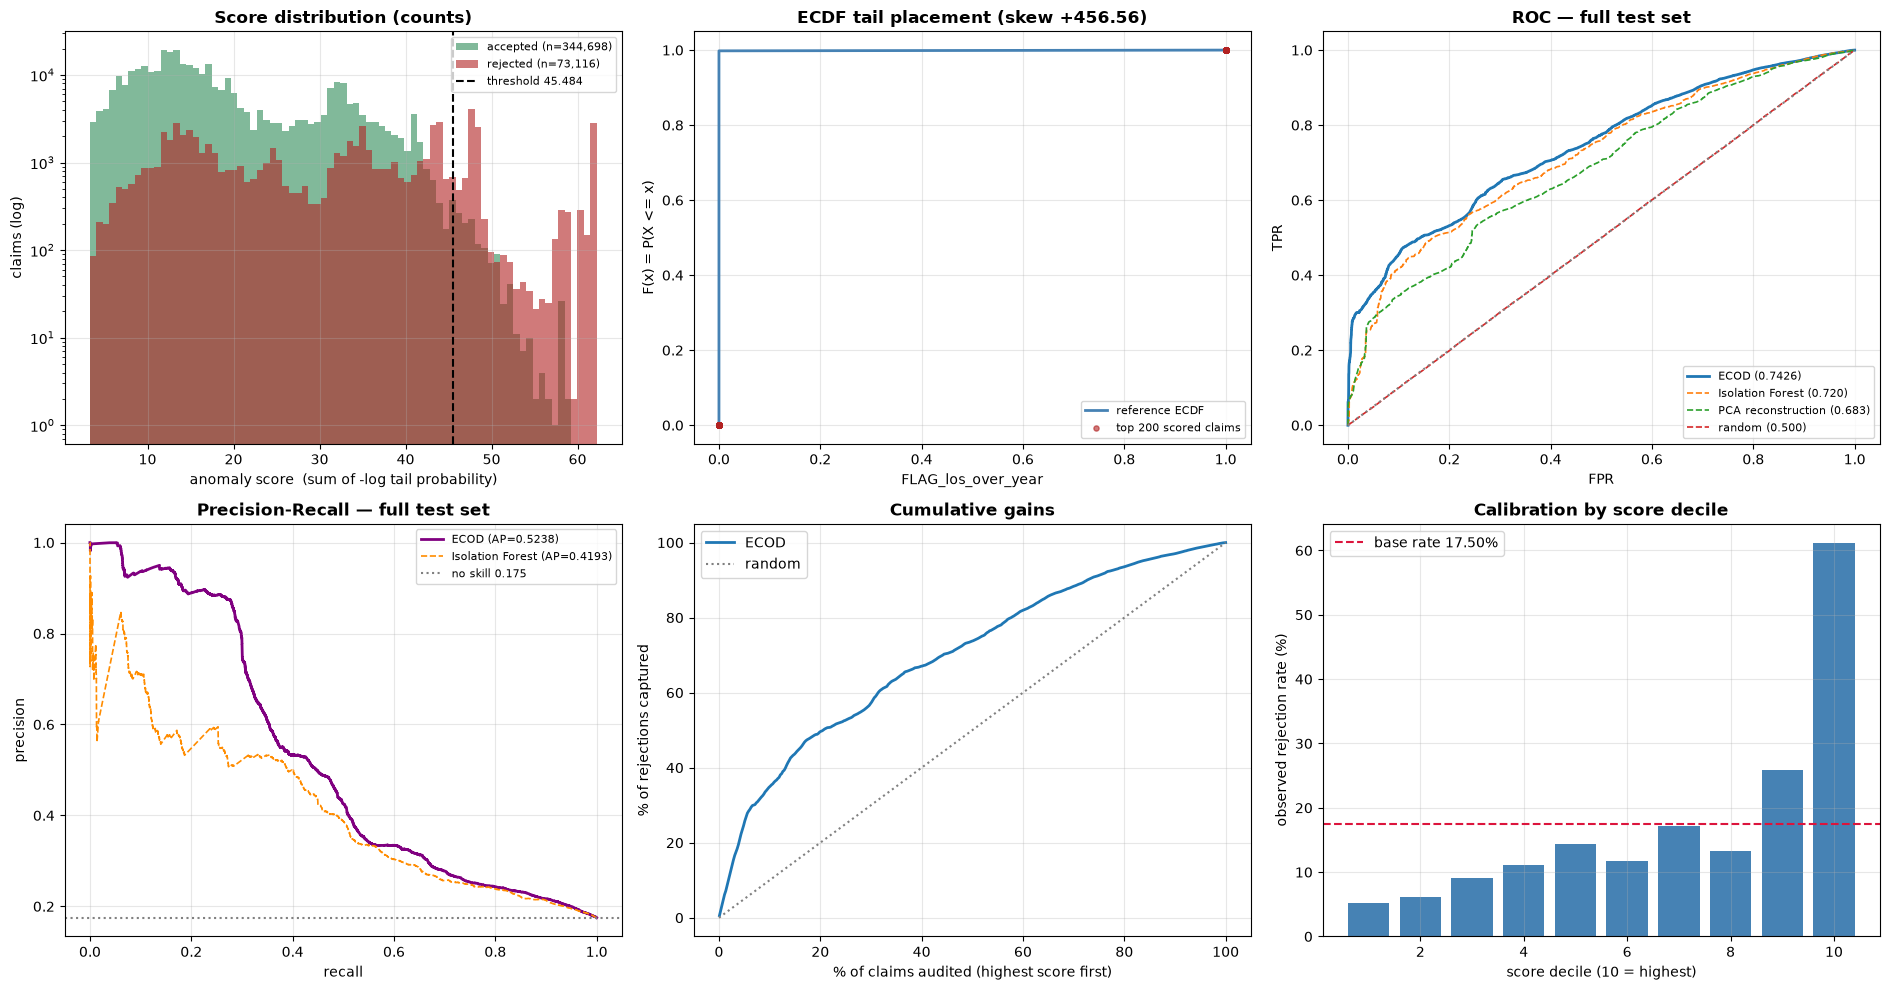

In [22]:
fig, ax = plt.subplots(2, 3, figsize=(19, 10))

a = ax[0, 0]
lo_, hi_ = np.percentile(test_scores, [0.1, 99.9])
bins = np.linspace(lo_, hi_, 80)
a.hist(test_scores[y_test == 0], bins=bins, color="seagreen", alpha=0.6,
       label=f"accepted (n={int((y_test==0).sum()):,})")
a.hist(test_scores[y_test == 1], bins=bins, color="firebrick", alpha=0.6,
       label=f"rejected (n={int((y_test==1).sum()):,})")
a.axvline(THRESHOLD, color="black", ls="--", label=f"threshold {THRESHOLD:.3f}")
a.set_yscale("log"); a.set_xlabel("anomaly score  (sum of -log tail probability)")
a.set_ylabel("claims (log)"); a.legend(fontsize=8)
a.set_title("Score distribution (counts)", fontweight="bold")

# the algorithm in one picture
a = ax[0, 1]
top_feat = int(np.argmax(np.abs(model.skew_)))
ref_col = model.ref_[:, top_feat]
q = np.linspace(0, 1, 500)
a.plot(np.quantile(ref_col, q), q, lw=2, color="steelblue", label="reference ECDF")
hi_claims = np.argsort(-test_scores)[:200]
a.scatter(X_test[hi_claims, top_feat],
          np.searchsorted(ref_col, X_test[hi_claims, top_feat]) / len(ref_col),
          color="firebrick", s=14, alpha=0.6, zorder=5, label="top 200 scored claims")
a.set_xlabel(FEATURE_NAMES[top_feat]); a.set_ylabel("F(x) = P(X <= x)")
a.legend(fontsize=8)
a.set_title(f"ECDF tail placement (skew {model.skew_[top_feat]:+.2f})", fontweight="bold")

a = ax[0, 2]
a.plot(*roc_curve(y_test, test_scores)[:2], lw=2, label=f"{VARIANT.upper()} ({ROC_AUC:.4f})")
for nm in ["Isolation Forest", "PCA reconstruction", "random"]:
    if nm in base:
        a.plot(*roc_curve(y_test, base[nm])[:2], lw=1.2, ls="--",
               label=f"{nm} ({roc_auc_score(y_test, base[nm]):.3f})")
a.plot([0, 1], [0, 1], color="grey", ls=":")
a.set_xlabel("FPR"); a.set_ylabel("TPR"); a.legend(loc="lower right", fontsize=8)
a.set_title("ROC — full test set", fontweight="bold")

a = ax[1, 0]
pr_, rc_, _ = precision_recall_curve(y_test, test_scores)
a.plot(rc_, pr_, lw=2, color="purple", label=f"{VARIANT.upper()} (AP={PR_AUC:.4f})")
if "Isolation Forest" in base:
    p2, r2, _ = precision_recall_curve(y_test, base["Isolation Forest"])
    a.plot(r2, p2, lw=1.2, ls="--", color="darkorange",
           label=f"Isolation Forest (AP={average_precision_score(y_test, base['Isolation Forest']):.4f})")
a.axhline(TEST_BASE_RATE, color="grey", ls=":", label=f"no skill {TEST_BASE_RATE:.3f}")
a.set_xlabel("recall"); a.set_ylabel("precision"); a.legend(fontsize=8)
a.set_title("Precision-Recall — full test set", fontweight="bold")

a = ax[1, 1]
kk = np.linspace(0.001, 1.0, 400)
gains = [cum[max(int(len(y_test)*k), 1)-1]/max(y_test.sum(), 1) for k in kk]
a.plot(kk*100, np.array(gains)*100, lw=2, label=VARIANT.upper())
a.plot([0, 100], [0, 100], color="grey", ls=":", label="random")
a.set_xlabel("% of claims audited (highest score first)")
a.set_ylabel("% of rejections captured"); a.legend()
a.set_title("Cumulative gains", fontweight="bold")

a = ax[1, 2]
dec = pd.qcut(pd.Series(test_scores).rank(method="first"), 10, labels=False)
obs_rate = pd.Series(y_test).groupby(dec).mean()
a.bar(obs_rate.index + 1, obs_rate.values*100, color="steelblue")
a.axhline(TEST_BASE_RATE*100, color="crimson", ls="--", label=f"base rate {TEST_BASE_RATE:.2%}")
a.set_xlabel("score decile (10 = highest)"); a.set_ylabel("observed rejection rate (%)")
a.legend(); a.set_title("Calibration by score decile", fontweight="bold")

for r_ in ax:
    for a_ in r_:
        a_.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## §17 — Facility-level view (D19)

Minimum-volume filter plus empirical-Bayes shrinkage, so a three-claim facility cannot top
the ranking. `Hfid` risk is an input feature, so this view is partly circular — a monitoring
aid, not independent evidence about a provider.

In [23]:
fac = pd.DataFrame({"Hfid": hfid_test, "score": test_scores, "y": y_test, "flagged": preds})
st = fac.groupby("Hfid").agg(claims=("score","size"), mean_score=("score","mean"),
                             flag_rate=("flagged","mean"), rej_rate=("y","mean")).reset_index()
g_mean = float(fac["score"].mean())
g_var  = float(st["mean_score"].var())
w_var  = float(fac.groupby("Hfid")["score"].var().mean())
k = w_var/max(g_var, 1e-12)
st["shrunk_score"] = (st["claims"]*st["mean_score"] + k*g_mean)/(st["claims"] + k)

elig = st[st["claims"] >= CONFIG["MIN_FACILITY_CLAIMS"]].copy()
print(f"Facilities in test      : {len(st):,}")
print(f"With >= {CONFIG['MIN_FACILITY_CLAIMS']} claims   : {len(elig):,}")
print(f"Shrinkage constant k    : {k:,.1f} claims-equivalent")
print(f"Excluded for low volume : {len(st)-len(elig):,}\n")
print("TOP 15 FACILITIES BY SHRUNK MEAN ANOMALY SCORE")
print(elig.sort_values("shrunk_score", ascending=False).head(15)
        .to_string(index=False, float_format=lambda v: f"{v:,.4f}"))
print("\nUnfiltered raw-mean ranking (what the original produced):")
print(st.sort_values("mean_score", ascending=False).head(5)[["Hfid","claims","mean_score"]]
        .to_string(index=False, float_format=lambda v: f"{v:,.4f}"))

Facilities in test      : 878
With >= 100 claims   : 440
Shrinkage constant k    : 0.7 claims-equivalent
Excluded for low volume : 438

TOP 15 FACILITIES BY SHRUNK MEAN ANOMALY SCORE
 Hfid  claims  mean_score  flag_rate  rej_rate  shrunk_score
  449    4075     58.6744     0.9350    0.9728       58.6680
 3898     907     54.1463     0.7431    1.0000       54.1206
 3890     130     49.1279     0.6077    0.8846       48.9762
 2360    6003     47.9240     0.9955    1.0000       47.9209
 2372     195     43.9582     0.6974    0.9590       43.8751
  836    4514     43.4849     0.0177    1.0000       43.4814
 3892    1531     43.1316     0.4233    0.7420       43.1214
 4406     364     41.5948     0.0165    0.1593       41.5546
  425     119     41.1319     0.0588    0.0420       41.0122
 3785     114     39.9145     0.0000    0.1228       39.7969
 1068     684     38.2786     0.0789    0.8494       38.2605
 4364     148     38.0002     0.0000    0.0203       37.9184
 4026     588     37.149

## §18 — Explainability, exact and free

**No SHAP required, and none should be used here.**

The score is defined as a sum of per-dimension terms:

`score(x) = Σⱼ −log(p̂ⱼ)`

so each term is *already* that dimension's exact, additive contribution. There is no
approximation to make, no background sample to choose, no run-to-run variance. Isolation
Forest needs TreeSHAP to reach this point; the autoencoder needs an approximation whose output
depends on which background set you pick.

There is a second gift here that neither of the others offers: because each contribution is a
**tail probability**, it converts straight into a sentence an auditor can read — "this claim's
submission delay is longer than 99.7% of accepted claims" — with no calibration step.

Highest-scoring flagged claim (test row 277,201)
  ClaimID       : 12143735
  Facility      : 3898
  Anomaly score : 76.4476  (99.99nd percentile)
  Actual label  : REJECTED (code 1)
  Contributions sum : 76.4476 == score   [exact, no approximation]

                     feature    value  pct_below_in_reference  tail_probability  contribution  pct_of_score
            NUM_LengthOfStay 414.0000                 99.9999            0.0000       13.6338       17.8341
          FLAG_los_over_year   1.0000                100.0000            0.0000       12.2475       16.0207
                 Icdid__risk   1.0597                 99.8683            0.0013        6.6325        8.6759
                  Hfid__risk   2.8900                 99.8452            0.0015        6.4710        8.4646
             Icdid__log_freq  -1.1992                  0.8934            0.0089        4.7179        6.1714
              NUM_CostPerDay  -2.0181                  1.5106            0.0151        4.1927        

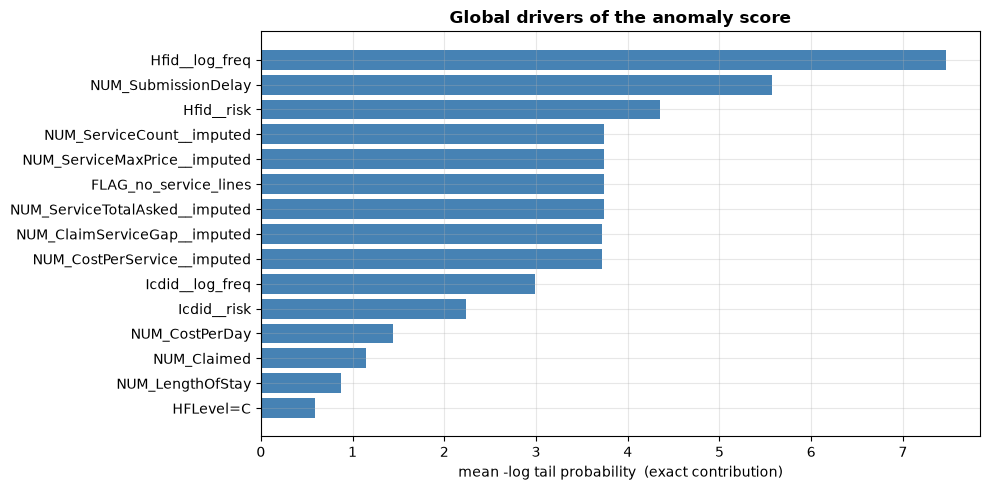

In [24]:
flagged = np.where(preds == 1)[0]
if len(flagged):
    pos = int(flagged[np.argmax(test_scores[flagged])])
    contrib = model.contributions(X_test[pos:pos+1], aggregation=AGG).ravel()
    left, right = model._tails(X_test[pos:pos+1])
    total = float(contrib.sum())

    top = np.argsort(-contrib)[:8]
    tbl = pd.DataFrame({
        "feature": [FEATURE_NAMES[t] for t in top],
        "value": X_test[pos, top],
        "pct_below_in_reference": left[0, top] * 100,
        "tail_probability": np.minimum(left[0, top], right[0, top]),
        "contribution": contrib[top],
        "pct_of_score": contrib[top] / max(total, 1e-12) * 100,
    })
    pctile = (test_scores < test_scores[pos]).mean() * 100
    print(f"Highest-scoring flagged claim (test row {pos:,})")
    print(f"  ClaimID       : {df['ClaimID'].values[idx_test][pos]}")
    print(f"  Facility      : {hfid_test[pos]}")
    print(f"  Anomaly score : {test_scores[pos]:.4f}  ({pctile:.2f}nd percentile)")
    print(f"  Actual label  : {'REJECTED' if y_test[pos] else 'accepted'} (code {rej_test[pos]})")
    print(f"  Contributions sum : {total:.4f} == score   [exact, no approximation]\n")
    print(tbl.to_string(index=False, float_format=lambda v: f"{v:,.4f}"))

    print("\nLayer 1 — what an auditor should actually see:")
    for _, r in tbl.head(3).iterrows():
        pb = r["pct_below_in_reference"]
        side = f"higher than {pb:.1f}%" if pb > 50 else f"lower than {100-pb:.1f}%"
        print(f"  - {r['feature']}: {side} of reference claims "
              f"({r['pct_of_score']:.0f}% of the anomaly score)")

    # global picture, on a sample of flagged claims
    rng = np.random.default_rng(SEED)
    sel = rng.choice(flagged, min(20_000, len(flagged)), replace=False)
    C = model.contributions(X_test[sel], aggregation=AGG)
    glob = pd.DataFrame({"feature": FEATURE_NAMES, "mean_contribution": C.mean(0)}) \
             .sort_values("mean_contribution", ascending=False)
    print(f"\nGLOBAL DRIVERS across {len(sel):,} flagged claims (leakage screen)")
    print(glob.head(15).to_string(index=False, float_format=lambda v: f"{v:.4f}"))
    share = glob["mean_contribution"].iloc[0] / glob["mean_contribution"].sum()
    print(f"\nTop feature accounts for {share:.1%} of total attribution.")
    if share > 0.40:
        print("  WARNING: one feature dominates. Check it is not a post-adjudication")
        print("  variable or a label proxy -- this is the pattern leakage makes.")
    else:
        print("  [ok] attribution spread across features, as expected without leakage.")

    plt.figure(figsize=(10, 5))
    plt.barh(glob["feature"].head(15)[::-1], glob["mean_contribution"].head(15)[::-1],
             color="steelblue")
    plt.xlabel("mean -log tail probability  (exact contribution)")
    plt.title("Global drivers of the anomaly score", fontweight="bold")
    plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
else:
    print("No claims flagged at the selected threshold.")

## §19 — Artefact export and model card

The exported artefact is tiny: one sorted array per feature plus a skewness vector. No weights,
no trees. It is also fully inspectable — a reviewer can read the reference quantiles directly.

In [25]:
np.savez_compressed(MODEL_DIR / "ecod_reference.npz",
                    ref=model.ref_.astype("float32"), skew=model.skew_,
                    feature_names=np.array(FEATURE_NAMES, dtype=object))
joblib.dump(scaler, MODEL_DIR / "scaler.pkl")
joblib.dump(enc,    MODEL_DIR / "encoders.pkl")

export = {
    "created": _dt.datetime.now().isoformat(timespec="seconds"),
    "model": VARIANT.upper(),
    "target": "ClaimStatus == 1 (claim REJECTION, not fraud)",
    "settings": {"variant": VARIANT, "aggregation": AGG, "reference_rows": REFERENCE,
                 "n_reference": int(model.n_ref_), "hyperparameters": "none"},
    "deterministic": True,
    "ecod_vs_copod_spearman": float(rho),
    "threshold": THRESHOLD, "threshold_mode": CONFIG["THRESHOLD_MODE"],
    "score_convention": "sum of -log tail probability; higher = more anomalous",
    "feature_names": FEATURE_NAMES,
    "split": {"mode": CONFIG["SPLIT_MODE"], "train_n": int(len(X_train_all)),
              "val_n": int(len(X_val)), "test_n": int(len(X_test))},
    "base_rates": {"population": POP_BASE_RATE, "validation": VAL_BASE_RATE,
                   "test": TEST_BASE_RATE},
    "metrics_test": {"roc_auc": float(ROC_AUC), "pr_auc": float(PR_AUC),
                     "precision": float(prec), "recall": float(rec), "f1": float(f1),
                     "alert_rate": float((tp+fp)/len(y_test)),
                     "roc_auc_ci95": [float(auc_lo), float(auc_hi)],
                     "pr_auc_ci95": [float(ap_lo), float(ap_hi)]},
    "baselines": bl.set_index("model")["PR_AUC"].to_dict(),
    "leakage_controls": {
        "post_adjudication_features_used": CONFIG["USE_POST_ADJUDICATION_FEATURES"],
        "encoders_fitted_on": "train window only",
        "max_feature_label_corr": float(cs.abs().max())},
    "config": {k: (list(v) if isinstance(v, tuple) else v) for k, v in CONFIG.items()},
}
with open(MODEL_DIR / "ecod_config.json", "w") as f:
    json.dump(export, f, indent=2, default=str)

card = f"""# Model Card — Claim Rejection {VARIANT.upper()}

**Created:** {export['created']}

## What this model does
Scores claims by the summed negative log tail probability of each feature under the empirical
CDF of a reference population. **The target is claim rejection, not fraud.** §15 quantifies
how much of that target is reachable at all.

## Configuration
- Variant {VARIANT.upper()}, aggregation '{AGG}', reference '{REFERENCE}' ({model.n_ref_:,} rows)
- **No hyperparameters.** Deterministic: refitting reproduces scores bit-for-bit (§11).
- ECOD vs COPOD Spearman rank correlation on this data: {rho:.4f}
- Split: {CONFIG['SPLIT_MODE']} — train {export['split']['train_n']:,} / val {export['split']['val_n']:,} / test {export['split']['test_n']:,}

## Performance (test)
- ROC-AUC {ROC_AUC:.4f} (95% CI {auc_lo:.4f}–{auc_hi:.4f}, clustered by facility)
- PR-AUC {PR_AUC:.4f} vs no-skill {TEST_BASE_RATE:.4f} ({PR_AUC/TEST_BASE_RATE:.2f}x)
- At threshold {THRESHOLD:.6f}: precision {prec:.4f}, recall {rec:.4f}, alert rate {(tp+fp)/len(y_test):.2%}

## Explainability
Exact by construction: the score is a sum of per-dimension contributions, each a tail
probability that reads directly as "higher than X% of reference claims". No SHAP needed.

## Known limitations
1. **Dimensions treated as independent.** Anomalies defined by feature *interactions* are
   invisible unless the interaction has been engineered into its own column.
2. Rejection is a weak proxy for fraud; several codes sit near AUC 0.5 by construction.
3. Facility risk is an input feature, so §17 is partly circular.
4. One-hot columns from rare categories contribute a large constant to every claim carrying
   that level.
5. Not validated prospectively.

## Intended use
Audit-queue triage alongside the existing rules engine, and as the **complexity baseline**
every other model must beat. Advisory only; all decisions human.
"""
(MODEL_DIR / "MODEL_CARD.md").write_text(card, encoding="utf-8")

print(f"Artefacts written to {MODEL_DIR}:")
for p in ["ecod_reference.npz", "scaler.pkl", "encoders.pkl", "ecod_config.json", "MODEL_CARD.md"]:
    fp = MODEL_DIR / p
    if fp.exists():
        print(f"  {p:<28} {fp.stat().st_size/1024:8.1f} KB")
np.save(MODEL_DIR / "ecod_test_scores.npy", test_scores)
print(f"  {'ecod_test_scores.npy':<28} (for the three-way comparison in §20)")

Artefacts written to C:\Projects\cameroon 3.0\model_ecod:
  ecod_reference.npz             1402.0 KB
  scaler.pkl                        1.0 KB
  encoders.pkl                     34.9 KB
  ecod_config.json                  3.6 KB
  MODEL_CARD.md                     1.7 KB
  ecod_test_scores.npy         (for the three-way comparison in §20)


## §20 — Three-way comparison

All three notebooks share §1–§6, so their test score arrays index the same claims in the same
order — provided each was run with the same `SPLIT_MODE`, `SAMPLE_FRAC` and `SEED`.

Add one line to the end of the other two notebooks:

```python
np.save(MODEL_DIR / "ae_test_scores.npy", test_errors)   # autoencoder notebook
np.save(MODEL_DIR / "if_test_scores.npy", test_scores)   # isolation forest notebook
```

**Combine by rank averaging, not score averaging.** Reconstruction error, negative path length
and summed log-tail-probability live on entirely different scales; averaging them raw lets
whichever has the widest range dominate.

**Check the rank correlations first.** An ensemble helps when component errors are
decorrelated. If two detectors correlate above ~0.85 they are finding the same claims and the
ensemble buys deployment cost without detection.

In [26]:
from scipy.stats import rankdata, spearmanr

paths = {"Autoencoder":      MODEL_DIR.parent / "model" / "ae_test_scores.npy",
         "Isolation Forest": MODEL_DIR.parent / "model_iforest" / "if_test_scores.npy"}
avail = {VARIANT.upper(): test_scores}
for nm, p in paths.items():
    if p.exists():
        s = np.load(p)
        if len(s) == len(test_scores):
            avail[nm] = s
        else:
            print(f"{nm}: length {len(s):,} != {len(test_scores):,} -- different split, skipped")
    else:
        print(f"{nm}: not found at {p}")

if len(avail) >= 2:
    names = list(avail)
    print("\nSpearman rank correlation between detectors:")
    corr = pd.DataFrame(index=names, columns=names, dtype=float)
    for a_ in names:
        for b_ in names:
            corr.loc[a_, b_] = 1.0 if a_ == b_ else spearmanr(avail[a_], avail[b_]).statistic
    print(corr.to_string(float_format=lambda v: f"{v:.3f}"))

    rows = [{"model": n, "ROC_AUC": roc_auc_score(y_test, s),
             "PR_AUC": average_precision_score(y_test, s)} for n, s in avail.items()]
    ens = np.mean([rankdata(s)/len(s) for s in avail.values()], axis=0)
    rows.append({"model": "Rank ensemble", "ROC_AUC": roc_auc_score(y_test, ens),
                 "PR_AUC": average_precision_score(y_test, ens)})
    res = pd.DataFrame(rows).sort_values("PR_AUC", ascending=False)
    print("\n" + res.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

    if res.iloc[0]["model"] == "Rank ensemble":
        best_single = res[res["model"] != "Rank ensemble"]["PR_AUC"].max()
        print(f"\nThe ensemble adds {res.iloc[0]['PR_AUC'] - best_single:+.4f} AP over the best")
        print("single model. Weigh that against running three pipelines in production.")
    else:
        print(f"\nThe ensemble does NOT beat its best component "
              f"({res.iloc[0]['model']}). Do not deploy it -- ship the single model.")
else:
    print("\nRun the other two notebooks with matching settings to enable this comparison.")

Autoencoder: not found at C:\Projects\cameroon 3.0\model\ae_test_scores.npy
Isolation Forest: not found at C:\Projects\cameroon 3.0\model_iforest\if_test_scores.npy

Run the other two notebooks with matching settings to enable this comparison.


---

## Where this leaves the study

You now have three detectors on one identical, leakage-free pipeline: a deep model, an
ensemble, and a parameter-free baseline. That is a genuinely publishable comparison — far
stronger than a single autoencoder reported without any reference point.

The result to look for in §14 and §20 is **whether complexity buys anything**. If ECOD matches
the autoencoder, the honest paper says so, and the deployable system is the one a ministry can
audit line by line.

The same three limits apply to all three notebooks:

1. **The target.** `ClaimStatus == 1` is rejection, not fraud, and §15 bounds how much of it
   is reachable. The higher-value targets remain the financial-deduction signal (653M XAF
   across 1.2M *accepted* claims) and the 412,890 line items with `PriceAsked / ServPrice > 1.5`.
2. **The unit of analysis.** Fraud is organised at provider level. Aggregating to ~30k
   facility-month profiles and running HDBSCAN + GLOSH there is cheap and likelier to produce
   findings an audit team can act on.
3. **Prospective validation.** Only a shadow pilot scored against independent human
   adjudication measures what you actually care about.